# 2D Double Integrator (Quadruped) Obstacle Avoidance — CBF Policy Comparison

State `(px, vx, py, vy)`, control `(ux, uy)` (accelerations), circular obstacle at origin.

Compares eight policies under persistent position-bias noise:
**Nominal · CBF · R-CBF-QP · Duality CBF · R-CBF (0.2) · R-CBF (1.0) · NMR-CBF · GUARDIAN**

Unlike Dubins3d (constant forward speed), the quadruped can stop in front of the obstacle:
`LGψ₁ = outward normal`, never zero, so CBF feasibility holds even at `v = 0`.

In [ ]:
import importlib
import functools as ft
import pickle
import sys
from pathlib import Path
sys.path.insert(0, '../../src')

import flax.linen as nn
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
import numpy as np
import optax

import hj_reachability as hj
from hjnnv import hjnnvUncertaintyAwareFilter
from jaxproxqp.jaxproxqp import JaxProxQP as _JaxProxQP
from jaxproxqp.qp_problems import QPModel as _QPModel

from mrncbf.utils.jax_utils import jax_default_x32
from mrncbf.qp.min_norm_cbf import min_norm_cbf, rcbf_qp_linear, compute_rcbf_gammas

# Shared primitives — see scripts/dbint/dbint2d_quad.py
# import dbint2d_quad
# importlib.reload(dbint2d_quad)
from dbint2d_quad import (
    UMAX, R_OBS, DT, T, ALPHA_HOCBF, ALPHA_QP,
    STATE_EPS, EPS_MAX, NMR_WEIGHTS_DIR,
    u_lb, u_ub,
    f, G, h_raw, B_hocbf, _cbf_ingredients,
    GOAL_MC, nom_pol_goto,
    PhiNet, phi_net,
)
# print(STATE_EPS)

jax_default_x32()

BASE_KEY        = jr.PRNGKey(0)
# _mc_results_dir = Path(NMR_WEIGHTS_DIR) / 'mc_results/full_scaling2x1'
_mc_results_dir = Path(NMR_WEIGHTS_DIR) / 'mc_results/full_scaling2x1_combined'
# _mc_results_dir = Path(NMR_WEIGHTS_DIR) / 'mc_results/vel0.1_obs0.25_alpha2.0'

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: cuDNN not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 614, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 233, in _check_cuda_versions
    cudnn_version = _version_check(
  File "/home/nrober/.pyenv/v

## Dynamics and HOCBF

`f(x) = [vx, 0, vy, 0]ᵀ`,  `G(x) = [[0,0],[1,0],[0,0],[0,1]]`.

`h(x) = R_OBS - ||p||`,  h < 0 safe.  Relative degree 2 → HOCBF ψ₁ = Lf h + α₀ h.
`LGψ₁ = outward normal` — never zero outside obstacle center.

In [2]:
# Dynamics, HOCBF, and `_cbf_ingredients` are imported from `dbint2d_quad`.
x_test = jnp.array([-2.0, 0.0, 0.0, 0.0])
print(f'h at safe state:  {float(h_raw(x_test)[0]):.3f}  (expect < 0)')
print(f'psi1 at safe state: {float(B_hocbf(x_test)[0]):.3f}')


h at safe state:  -1.750  (expect < 0)
psi1 at safe state: -3.500


## Observation model and rollout infrastructure

In [3]:
# `GOAL_MC` and `nom_pol_goto` are imported from `dbint2d_quad`.
def _box_bounds(xhat):
    return xhat - STATE_EPS, xhat + STATE_EPS

def _make_rollout(step_fn, goal=GOAL_MC):
    """Return a @jax.jit rollout(x0, bias) → (xs, xhats) suitable for jax.vmap."""
    @jax.jit
    def rollout(x0, bias):
        def _scan_step(carry, step_idx):
            return step_fn(carry, step_idx, goal)
        _, (xs, xhats) = jax.lax.scan(_scan_step, (x0, bias), jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0), xhats
    return rollout

def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    x0s = lo[None] + jr.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

ts      = np.arange(T + 1) * DT
ts_ctrl = np.arange(T) * DT


## Nominal and CBF policies

In [4]:
def _nom_step(carry, step_idx, goal):
    x, bias = carry
    xhat = x + bias
    u = nom_pol_goto(xhat, goal)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

def _cbf_step(carry, step_idx, goal):
    x, bias = carry
    xhat = x + bias
    h_B = B_hocbf(xhat)
    J_B = jax.jacobian(B_hocbf)(xhat)
    u_nom = nom_pol_goto(xhat, goal)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, J_B,
                            f(xhat), G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

## R-CBF-QP

In [5]:
N_RCBF_SAMPLES = 20

def _rcbf_step(carry, step_idx, goal):
    x, bias    = carry
    xhat       = x + bias
    samp_key   = jr.fold_in(BASE_KEY, step_idx)
    lo, hi     = _box_bounds(xhat)
    h_V_nom    = B_hocbf(xhat)
    hx_Vx_nom  = jax.jacobian(B_hocbf)(xhat)
    u_nom      = nom_pol_goto(xhat, goal)
    x_pert     = lo[None] + jr.uniform(samp_key, (N_RCBF_SAMPLES, 4)) * (hi - lo)
    h_V_pert   = jax.vmap(B_hocbf)(x_pert)
    hx_Vx_pert = jax.vmap(jax.jacobian(B_hocbf))(x_pert)
    f_pert     = jax.vmap(f)(x_pert)
    G_pert     = jax.vmap(G)(x_pert)
    u_nom_pert = jax.vmap(lambda xp: nom_pol_goto(xp, goal))(x_pert)
    gamma1, gamma2 = compute_rcbf_gammas(
        ALPHA_QP, u_lb, u_ub,
        h_V_nom, hx_Vx_nom, f(xhat), G(xhat), u_nom,
        h_V_pert, hx_Vx_pert, f_pert, G_pert, u_nom_pert, n_grid=50)
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub, h_V_nom, hx_Vx_nom,
                              f(xhat), G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

## Duality CBF

Builds a polytope over-approximation of the 3D image set
`{ [LGψ₁[0](x), LGψ₁[1](x), Lfψ₁(x)+α·ψ₁(x)] : x ∈ uncertainty box }`
via Fibonacci-sphere support functions, then solves a QP using LP duality.

Generalised from the Dubins3d (NU=1, 2D image) to NU=2 (3D image on S²).

In [6]:
N_PLANES_DUAL = 16
_golden    = (1 + np.sqrt(5)) / 2
_ks        = np.arange(N_PLANES_DUAL)
_theta_fib = np.arccos(1 - 2*(_ks + 0.5) / N_PLANES_DUAL)
_phi_fib   = 2*np.pi*_ks / _golden
_DUAL_DIRS = np.stack([
    np.sin(_theta_fib)*np.cos(_phi_fib),
    np.sin(_theta_fib)*np.sin(_phi_fib),
    np.cos(_theta_fib),
], axis=1)   # (N_PLANES_DUAL, 3) — Fibonacci sphere directions on S²

def _image_fn(x, alpha=ALPHA_HOCBF):
    h_B, Lf_B, LG_B = _cbf_ingredients(x, alpha)
    return jnp.array([LG_B[0, 0], LG_B[0, 1], Lf_B[0] + ALPHA_QP*h_B[0]])

def _duality_cbf_qp(C_poly, d_poly, u_nom, relax_eps=0.1, penalty=10.0):
    """Duality-based CBF QP for NU=2.

    Variables: z = [λ₁..λN, u1, u2, r]
    Equality:  C_poly.T @ λ = [u1; u2; 1]   (LP dual certificate)
    Inequality: d_poly.T @ λ ≤ r             (worst-case CBF ≤ slack)
    """
    N = C_poly.shape[0]
    n = N + 3

    H = jnp.zeros((n, n))
    H = H.at[N,   N  ].set(1.0)
    H = H.at[N+1, N+1].set(1.0)
    H = H.at[N+2, N+2].set(penalty)

    g = jnp.zeros(n)
    g = g.at[N  ].set(-u_nom[0])
    g = g.at[N+1].set(-u_nom[1])
    g = g.at[N+2].set(penalty * relax_eps)

    A_eq = jnp.zeros((3, n))
    A_eq = A_eq.at[:, :N].set(C_poly.T)
    A_eq = A_eq.at[0, N  ].set(-1.0)
    A_eq = A_eq.at[1, N+1].set(-1.0)
    b_eq = jnp.array([0.0, 0.0, 1.0])

    C_ineq = jnp.zeros((1, n))
    C_ineq = C_ineq.at[0, :N].set(d_poly)
    C_ineq = C_ineq.at[0, N+2].set(-1.0)
    l_ineq = jnp.array([-1e8])
    u_ineq = jnp.array([0.0])

    l_box = jnp.concatenate([jnp.zeros(N), u_lb, jnp.array([-relax_eps])])
    u_box = jnp.concatenate([jnp.full(N, 1e8), u_ub, jnp.array([1e8])])

    qp  = _QPModel(H, g, A_eq, C_ineq, b_eq, u_ineq, l_ineq, u_box, l_box)
    sol = _JaxProxQP(qp, _JaxProxQP.Settings.default()).solve()
    return sol.x[N:N+2], sol.x[N+2], sol

def _duality_step(carry, step_idx, goal):
    x, bias  = carry
    xhat     = x + bias
    lo, hi   = _box_bounds(xhat)
    u_nom    = nom_pol_goto(xhat, goal)
    opt_key  = jr.fold_in(BASE_KEY, step_idx)
    all_keys = jr.split(opt_key, N_PLANES_DUAL)

    def _support_one(d_vec, k_j):
        val, _ = proj_grad_max_box(
            lambda xi: d_vec @ _image_fn(xi), lo, hi,
            n_restarts=2, n_steps=15, lr=0.05, key=k_j)
        return val

    d_poly = jax.vmap(_support_one)(_DUAL_DIRS, all_keys)
    u, _, _ = _duality_cbf_qp(_DUAL_DIRS, d_poly, u_nom)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

## R-CBF with fixed γ

In [7]:
def _make_rcbf_fixed_step(gamma_val):
    def _step(carry, step_idx, goal):
        x, bias   = carry
        xhat      = x + bias
        h_V_nom   = B_hocbf(xhat)
        hx_Vx_nom = jax.jacobian(B_hocbf)(xhat)
        u_nom     = nom_pol_goto(xhat, goal)
        u, _, _   = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub, h_V_nom, hx_Vx_nom,
                                    f(xhat), G(xhat), u_nom,
                                    gamma1=gamma_val, gamma2=gamma_val, relax_eps2=0.1)
        return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)
    return _step

## MR-CBF — Lipschitz tightening

Conservative Lipschitz-based tightening of the CBF barrier.  For all $x \in [\hat x - \varepsilon, \hat x + \varepsilon]$:

$$L_f B(x) + L_G B(x)\,u + \alpha B(x)
  \;\le\;
  L_f B(\hat x) + L_G B(\hat x)\,u + \alpha B(\hat x)
  + \sum_i \varepsilon_i L^{L_f B}_i
  + \sum_i \varepsilon_i \alpha L^{B}_i
  + \sum_i \varepsilon_i L^{L_G B}_i \cdot \|u\|_2$$

Bounding $\|u\|_2 \le \sqrt{n_u}\,u_{\max}$ gives a state-independent scalar $\phi_{\mathrm{MR}}$, reducing the step to a standard CBF-QP with $h_{\mathrm{tight}} = B(\hat x) + \phi_{\mathrm{MR}} / \alpha$.

In [8]:
# ── Per-dim Lipschitz constant estimation ────────────────────────────────────
# Estimates max |∂ B / ∂x_i|, |∂ Lf B / ∂x_i|, ||∂ LG B / ∂x_i||_2
# via finite differences over states outside the obstacle.
# Runs once at notebook startup; result is O(seconds).

def _estimate_lipschitz_per_dim(n_samples=5000, delta=1e-3, margin=0.05):
    rng = np.random.default_rng(123)
    x_lo = np.array([-2.5, -1.5, -2.5, -1.5])
    x_hi = np.array([ 2.5,  1.5,  2.5,  1.5])
    n_cand = n_samples * 5
    xs_cand = x_lo + rng.random((n_cand, 4)) * (x_hi - x_lo)
    dist = np.sqrt(xs_cand[:, 0]**2 + xs_cand[:, 2]**2)
    outside = dist > (R_OBS + margin)
    xs = xs_cand[outside][:n_samples]
    print(f"  {outside.sum()}/{n_cand} outside obstacle, using {len(xs)}")

    @jax.jit
    def _ingredients(xi):
        h_B  = B_hocbf(xi)                      # (1,)
        J_B  = jax.jacobian(B_hocbf)(xi)        # (1, 4)
        Lf_B = J_B @ f(xi)                       # (1,)
        LG_B = J_B @ G(xi)                       # (1, 2)
        return jnp.concatenate([h_B, Lf_B, LG_B.ravel()])  # (4,)

    _vmap_ing = jax.jit(jax.vmap(_ingredients))
    vals = np.array(_vmap_ing(jnp.array(xs, dtype=jnp.float32)))  # (n, 4)

    L_B_dim  = np.zeros(4)
    L_Lf_dim = np.zeros(4)
    L_LG_dim = np.zeros(4)
    for dim in range(4):
        xs_p = xs.copy(); xs_p[:, dim] += delta
        mask = np.sqrt(xs_p[:, 0]**2 + xs_p[:, 2]**2) > (R_OBS + margin)
        dv = np.abs(np.array(_vmap_ing(jnp.array(xs_p[mask], dtype=jnp.float32)))
                    - vals[mask]) / delta
        L_B_dim[dim]  = dv[:, 0].max()
        L_Lf_dim[dim] = dv[:, 1].max()
        # LG_B is (1, 2): cols 2 and 3 are the two control channels
        L_LG_dim[dim] = np.sqrt(dv[:, 2]**2 + dv[:, 3]**2).max()

    return L_B_dim, L_Lf_dim, L_LG_dim

print('Estimating Lipschitz constants (MR-CBF)...')
_L_B_dim, _L_Lf_dim, _L_LG_dim = _estimate_lipschitz_per_dim()
_L_ah_dim = ALPHA_QP * _L_B_dim   # alpha * L_B

_eps_arr       = np.array(STATE_EPS)                            # (4,)
_tight_Lf_ah   = float(np.sum(_eps_arr * (_L_Lf_dim + _L_ah_dim)))
_tight_LG      = float(np.sum(_eps_arr * _L_LG_dim))
# Conservative bound ||u||_2 <= sqrt(nu) * UMAX = sqrt(2) * 1.0
_tight_LG_eff  = _tight_LG * UMAX * float(np.sqrt(2))
_phi_mrcbf     = 0.1*(_tight_Lf_ah + _tight_LG_eff)

print(f"Per-dim  L_B : {_L_B_dim.round(3)}")
print(f"Per-dim  L_Lf: {_L_Lf_dim.round(3)}")
print(f"Per-dim  L_LG: {_L_LG_dim.round(3)}")
print(f"tight_Lf_ah  = {_tight_Lf_ah:.4f}")
print(f"tight_LG_eff = {_tight_LG_eff:.4f}  (tight_LG={_tight_LG:.4f} × UMAX×√2)")
print(f"φ_MR         = {_phi_mrcbf:.4f}   (added to h_B / ALPHA_QP)")


Estimating Lipschitz constants (MR-CBF)...
  24719/25000 outside obstacle, using 5000
Per-dim  L_B : [5.09  1.    4.689 1.   ]
Per-dim  L_Lf: [31.337  8.775 25.048  8.829]
Per-dim  L_LG: [3.26  0.    3.237 0.   ]
tight_Lf_ah  = 7.5967
tight_LG_eff = 0.9188  (tight_LG=0.6497 × UMAX×√2)
φ_MR         = 0.8516   (added to h_B / ALPHA_QP)


In [38]:
# def _mrcbf_step(carry, step_idx, goal):
#     """MR-CBF: fixed Lipschitz tightening of the CBF barrier.

#     Tightens B(x̂) by φ_MR/α before solving the CBF-QP, guaranteeing that
#     the CBF constraint holds for every x in the uncertainty box [x̂-ε, x̂+ε].
#     φ_MR = tight_Lf_ah + tight_LG_eff (precomputed from Lipschitz constants).

#     Equivalent to the (commented-out) cvxpy MR-CBF in dubins3d_cbf_compare_r2,
#     but fully JAX-JIT-compatible because G(x) is constant for the double
#     integrator, so ||u||_2 ≤ UMAX√nu is a static bound on the LG term.
#     """
#     x, bias   = carry
#     xhat      = x + bias
#     h_B       = B_hocbf(xhat)                        # (1,)
#     J_B       = jax.jacobian(B_hocbf)(xhat)          # (1, 4)
#     u_nom     = nom_pol_goto(xhat, goal)
#     # Tighten: h_tight = B + φ_MR/α  (more positive ⟹ QP is more conservative)
#     h_tight   = h_B + _phi_mrcbf / ALPHA_QP
#     u, _, _   = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_tight, J_B,
#                               f(xhat), G(xhat), u_nom, relax_eps2=0.1)
#     return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

# ── Corrected MR-CBF step: JAX-native, faithful to Dean et al. 2020 ─────────
# Precompute tightening terms (split: constant + ||u||_2 coefficient)
_eps_arr        = np.array(STATE_EPS)
_tight_const_np = float(np.sum(_eps_arr * (_L_Lf_dim + _L_ah_dim)))   # constant part
_tight_LG_np    = float(np.sum(_eps_arr * _L_LG_dim))                  # coeff of ||u||_2

print(f"MR-CBF tightening: const = {_tight_const_np:.4f}, "
      f"||u||_2 coeff = {_tight_LG_np:.4f}")

_TIGHT_CONST = jnp.asarray(_tight_const_np)
_TIGHT_LG    = jnp.asarray(_tight_LG_np)

def _mrcbf_step(carry, step_idx, goal):
    """Faithful MR-CBF (Dean et al. 2020, eq MR-OP) via JAX bisection on ||u||_2.
    
    Original constraint:
        Lf h(x̂) + Lg h(x̂) u + α h(x̂)  >=  C + K * ||u||_2
    where C = tight_const, K = tight_LG_norm.
    
    Strategy: for fixed s = ||u||_2, this is a standard CBF-QP with tightened
    barrier h_eff = h - (C + K*s)/α. We bisect s until self-consistent.
    """
    x, bias = carry
    xhat    = x + bias
    h_B     = B_hocbf(xhat)
    J_B     = jax.jacobian(B_hocbf)(xhat)
    f_xh    = f(xhat)
    G_xh    = G(xhat)
    u_nom   = nom_pol_goto(xhat, goal)

    def qp_given_s(s):
        # Tighten the CBF condition by the s-dependent amount
        phi     = _TIGHT_CONST + _TIGHT_LG * s
        h_tight = h_B + phi / ALPHA_QP            # NB: minus, not plus
        u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_tight, J_B,
                               f_xh, G_xh, u_nom, relax_eps2=0.1)
        return u

    # Fixed-point iteration on s. Damped to avoid oscillation.
    def body(s, _):
        u_s   = qp_given_s(s)
        s_new = jnp.linalg.norm(u_s)
        return 0.5 * s + 0.5 * s_new, None

    s0 = jnp.linalg.norm(u_nom)
    s_final, _ = jax.lax.scan(body, s0, None, length=8)
    u = qp_given_s(s_final)

    return (x + DT * (f(x) + G(x) @ u), bias), (x, xhat)


MR-CBF tightening: const = 7.5967, ||u||_2 coeff = 0.6497


## NMR-CBF — Learning φ

`φ(x̂, ε) ≥ max_{x∈[x̂-ε, x̂+ε]}[Lfψ₁(x)+α·ψ₁(x)] - [Lfψ₁(x̂)+α·ψ₁(x̂)]`

Network input is `(x̂, ε)` concatenated — trains across `ε ~ Uniform[0, EPS_MAX]` so
the same weights generalise to any noise level up to `EPS_MAX`.  At runtime pass
the actual `STATE_EPS` used in rollouts.

Weights saved to `NMR_WEIGHTS_DIR/phi_params.pkl`; loaded automatically if present.

In [10]:
PHI_MAX = 8.0   # cap labels against outliers near the obstacle boundary

@ft.partial(jax.jit, static_argnames=('n_restarts', 'n_steps'))
def phi_true_fn(xhat, eps, key, n_restarts=8, n_steps=60, lr=0.05):
    """φ_i(x̂, ε) = max_{x∈[x̂-ε, x̂+ε]} (Lfψ₁+αψ₁)(x) - (Lfψ₁+αψ₁)(x̂), clipped ≥ 0."""
    lo     = xhat - eps
    hi     = xhat + eps
    h_nom  = B_hocbf(xhat)
    Lf_nom = jax.jacobian(B_hocbf)(xhat) @ f(xhat)
    def worst_i(i, k):
        _, x_wc = proj_grad_max_box(
            lambda x: (jax.jacobian(B_hocbf)(x) @ f(x) + ALPHA_QP * B_hocbf(x))[i],
            lo, hi, n_restarts, n_steps, lr, k)
        h_wc  = B_hocbf(x_wc)[i]
        Lf_wc = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
        delta = (Lf_wc + ALPHA_QP * h_wc) - (Lf_nom[i] + ALPHA_QP * h_nom[i])
        return jnp.clip(delta, 0.0, PHI_MAX)
    keys = jr.split(key, 1)
    return jax.vmap(worst_i)(jnp.arange(1), keys)   # (1,)

# `PhiNet` and `phi_net` are imported from `dbint2d_quad`.

_nmr_dir           = Path(NMR_WEIGHTS_DIR)
_nmr_pretrain_file = _nmr_dir / 'phi_params.pkl'
_nmr_finetune_file = _nmr_dir / 'phi_params_finetune_rl_v1.pkl'

# ── Load or train pretrained weights ─────────────────────────────────────────
if _nmr_pretrain_file.exists():
    with open(_nmr_pretrain_file, 'rb') as _f:
        _phi_params_pretrain = pickle.load(_f)
    print(f'Loaded NMR-CBF (pretrain) weights from {_nmr_pretrain_file}')
else:
    _phi_params_pretrain = phi_net.init(jr.PRNGKey(0), jnp.zeros(4), jnp.zeros(4))['params']
    n_params   = sum(p.size for p in jax.tree_util.tree_leaves(_phi_params_pretrain))
    print(f'Training PhiNet ({n_params} params, input=8, output=1)...')

    x_lo = jnp.array([-3., -2., -3., -2.])
    x_hi = jnp.array([ 3.,  2.,  3.,  2.])
    N_TRAIN, N_TEST = 20000, 5000
    rng_phi = jr.PRNGKey(7)
    rng_phi, rng_tr, rng_te, rng_eps_tr, rng_eps_te = jr.split(rng_phi, 5)

    def _outside(xh):
        return jnp.sqrt(xh[0]**2 + xh[2]**2) > R_OBS + 0.1

    cands_tr   = x_lo + jr.uniform(rng_tr, (N_TRAIN * 2, 4)) * (x_hi - x_lo)
    cands_te   = x_lo + jr.uniform(rng_te, (N_TEST  * 2, 4)) * (x_hi - x_lo)
    xhat_train = cands_tr[jax.vmap(_outside)(cands_tr)][:N_TRAIN]
    xhat_test  = cands_te[jax.vmap(_outside)(cands_te)][:N_TEST]

    # eps sampled per-sample from Uniform[0, EPS_MAX] — network generalises across noise levels
    eps_train = jr.uniform(rng_eps_tr, (N_TRAIN, 4)) * EPS_MAX
    eps_test  = jr.uniform(rng_eps_te, (N_TEST,  4)) * EPS_MAX

    keys_tr = jr.split(jr.PRNGKey(1), N_TRAIN)
    keys_te = jr.split(jr.PRNGKey(2), N_TEST)

    print('  Computing phi_true (training)...')
    phi_train = jax.vmap(phi_true_fn)(xhat_train, eps_train, keys_tr)
    print('  Computing phi_true (test)...')
    phi_test  = jax.vmap(phi_true_fn)(xhat_test,  eps_test,  keys_te)
    print(f'  phi: mean={float(jnp.mean(phi_train)):.4f}  '
          f'max={float(jnp.max(phi_train)):.4f}  min={float(jnp.min(phi_train)):.4f}')

    optimizer = optax.adam(3e-3)
    opt_state = optimizer.init(_phi_params_pretrain)

    @jax.jit
    def train_step(params, opt_state, xhat_b, eps_b, phi_b):
        def loss_fn(p):
            pred = jax.vmap(lambda x, e: phi_net.apply({'params': p}, x, e))(xhat_b, eps_b)
            return jnp.mean((pred - phi_b) ** 2)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt = optimizer.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), new_opt, loss

    rng_ep = jr.PRNGKey(42)
    for epoch in range(400):
        rng_ep, rng_s = jr.split(rng_ep)
        perm = jr.permutation(rng_s, N_TRAIN)
        for b in range(0, N_TRAIN, 256):
            idx = perm[b : b + 256]
            _phi_params_pretrain, opt_state, ep_loss = train_step(
                _phi_params_pretrain, opt_state, xhat_train[idx], eps_train[idx], phi_train[idx])
        if (epoch + 1) % 100 == 0:
            pred_val = jax.vmap(lambda x, e: phi_net.apply({'params': _phi_params_pretrain}, x, e))(
                xhat_test, eps_test)
            val_mse = float(jnp.mean((pred_val - phi_test) ** 2))
            print(f'  Epoch {epoch+1:3d}  train_loss={ep_loss:.3e}  val_mse={val_mse:.3e}')

    _nmr_dir.mkdir(parents=True, exist_ok=True)
    with open(_nmr_pretrain_file, 'wb') as _f:
        pickle.dump(_phi_params_pretrain, _f)
    print(f'Saved NMR-CBF (pretrain) weights to {_nmr_pretrain_file}')

# ── Load RL fine-tuned weights (no training fallback) ────────────────────────
if _nmr_finetune_file.exists():
    with open(_nmr_finetune_file, 'rb') as _f:
        _phi_params_finetune = pickle.load(_f)
    print(f'Loaded NMR-CBF (RL) weights from {_nmr_finetune_file}')
else:
    _phi_params_finetune = None
    print(f'NMR-CBF (RL) weights not found at {_nmr_finetune_file} — will reuse pretrain weights')


Loaded NMR-CBF (pretrain) weights from /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_dbint2d/policies/obs0.25/phi_params.pkl
Loaded NMR-CBF (RL) weights from /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_dbint2d/policies/obs0.25/phi_params_finetune_rl_v1.pkl


In [11]:
def _make_nmr_step(phi_params_frozen):
    def _nmr_step(carry, step_idx, goal):
        x, bias   = carry
        xhat      = x + bias
        phi       = phi_net.apply({'params': phi_params_frozen}, xhat, STATE_EPS)
        h_B       = B_hocbf(xhat)
        J_B       = jax.jacobian(B_hocbf)(xhat)
        u_nom     = nom_pol_goto(xhat, goal)
        u, _, _   = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B + phi/ALPHA_QP, J_B,
                                  f(xhat), G(xhat), u_nom, relax_eps2=0.1)
        return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)
    return _nmr_step

_nmr_pretrain_step = _make_nmr_step(_phi_params_pretrain)
_phi_rl            = _phi_params_finetune if _phi_params_finetune is not None else _phi_params_pretrain
_nmr_finetune_step = _make_nmr_step(_phi_rl)

## φ-oracle CBF — worst-case Lf+αh, nominal LG

Like NMR-CBF but computes φ exactly at runtime via projected-gradient ascent instead
of using a learned network.  The QP constraint is:

$$\max_{x\in[\hat x-\varepsilon,\,\hat x+\varepsilon]}\!\bigl[L_f\psi_1(x)+\alpha\psi_1(x)\bigr]
+ L_G\psi_1(\hat x)\,u \;\le\; 0$$

Worst-case is computed per constraint via `proj_grad_max_box` (same oracle used to
label the NMR-CBF training data).  Passed to `min_norm_cbf` identically to NMR-CBF
via the tightened barrier `h_nom + φ_oracle/α`.


In [12]:
def _lfhwc_step(carry, step_idx, goal):
    x, bias   = carry
    xhat      = x + bias
    lo, hi    = _box_bounds(xhat)              # per-dim box from STATE_EPS vector
    u_nom     = nom_pol_goto(xhat, goal)
    opt_key   = jr.fold_in(BASE_KEY, step_idx)

    # Nominal ingredients — J_nom carries LG, keeping it at xhat
    h_nom  = B_hocbf(xhat)                    # (nh,)
    J_nom  = jax.jacobian(B_hocbf)(xhat)      # (nh, nx)
    Lf_nom = J_nom @ f(xhat)                  # (nh,)

    # Per-constraint oracle: maximize Lf ψ₁ + α ψ₁ over the uncertainty box
    nh   = h_nom.shape[0]
    keys = jr.split(opt_key, nh)

    def worst_i(i, k):
        _, x_wc = proj_grad_max_box(
            lambda xi: (jax.jacobian(B_hocbf)(xi) @ f(xi) + ALPHA_QP * B_hocbf(xi))[i],
            lo, hi, n_restarts=4, n_steps=25, lr=0.05, key=k)
        h_wc_i  = B_hocbf(x_wc)[i]
        Lf_wc_i = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
        return h_wc_i, Lf_wc_i

    h_wc, Lf_wc = jax.vmap(worst_i)(jnp.arange(nh), keys)   # (nh,), (nh,)

    # phi_oracle = max(Lf ψ₁ + α ψ₁) − nom(Lf ψ₁ + α ψ₁)  — same quantity NMR-CBF learns
    phi_oracle = (Lf_wc + ALPHA_QP * h_wc) - (Lf_nom + ALPHA_QP * h_nom)

    # Identical call to NMR-CBF; only the source of phi differs
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_nom + phi_oracle / ALPHA_QP, J_nom,
                            f(xhat), G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT * (f(x) + G(x) @ u), bias), (x, xhat)


## GUARDIAN

All components computed inline — no file loading required.
Note: 4D grid (40⁴ ≈ 2.56M points) is coarser than Dubins3d (100³ = 1M) to keep memory tractable.

In [13]:
class DoubleInt2DHJ(hj.ControlAndDisturbanceAffineDynamics):
    def __init__(self, umax=1.0, max_disturbance=1e-1, dt=DT,
                 control_mode='max', disturbance_mode='min'):
        super().__init__(
            control_space=hj.sets.Box(np.array([-umax,-umax]), np.array([umax, umax])),
            disturbance_space=hj.sets.Box(np.array([-max_disturbance]*4), np.array([max_disturbance]*4)),
            control_mode=control_mode, disturbance_mode=disturbance_mode)
        self._umax = umax
        self.dt = dt
        
    def open_loop_dynamics(self, state, time):
        px, vx, py, vy = state
        return jnp.array([vx, 0.0, vy, 0.0])
    def control_jacobian(self, state, time):
        return jnp.array([[0.,0.],[1.,0.],[0.,0.],[0.,1.]]) * self._umax
    def disturbance_jacobian(self, state, time):
        return jnp.eye(4)
    def step(self, state, control, disturbance, time=0.):
        return state + self(state, control, disturbance, time) * self.dt

N_GRID      = 60
hj_dynamics = DoubleInt2DHJ(umax=UMAX)
hj_grid     = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(np.array([-3.,-2.,-3.,-2.]), np.array([3., 2., 3., 2.])),
    (N_GRID,)*4)
hj_initial_values = -R_OBS**2 + hj_grid.states[...,0]**2 + hj_grid.states[...,2]**2

guardian_filter = hjnnvUncertaintyAwareFilter(
    dynamics=hj_dynamics,
    pred_model=lambda obs: obs,
    grid=hj_grid,
    initial_values=hj_initial_values,
    num_controls=10,
    num_disturbances=3,
)
print('GUARDIAN filter initialised.')

100%|##########| 10.0000/10.0 [01:26<00:00,  8.69s/sim_s]


GUARDIAN filter initialised.


## Safety set visualisation — slice at vx=1, vy=0

Plot `h(x)` and `ψ₁(x)` over the XY plane with the HJ backward-reachable tube zero-level-set (dashed black) overlaid as a ground-truth safety boundary.
Slice: `vx = VX_SLICE = 1.0`, `vy = VY_SLICE = 0.0`.

In [14]:
VX_SLICE = 1.0
VY_SLICE = 0.0

# --- HJ backward reachable tube (coarser grid for speed) ---
N_VIZ_GRID = 40
hj_grid_viz = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(np.array([-3., -2., -3., -2.]), np.array([3., 2., 3., 2.])),
    (N_VIZ_GRID,) * 4)
hj_initial_viz = -R_OBS**2 + hj_grid_viz.states[..., 0]**2 + hj_grid_viz.states[..., 2]**2

print(f'Computing HJ backward reachable tube on {N_VIZ_GRID}^4 grid...')
_solver_settings = hj.SolverSettings.with_accuracy(
    'high', hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)
hj_target_viz = hj.step(_solver_settings, hj_dynamics, hj_grid_viz, 0.0, hj_initial_viz, -5.0)
print('Done.')

# Slice at (vx, vy) — grid dim order: px=0, vx=1, py=2, vy=3
_cvecs   = hj_grid_viz.coordinate_vectors
_vx_idx  = int(np.argmin(np.abs(np.array(_cvecs[1]) - VX_SLICE)))
_vy_idx  = int(np.argmin(np.abs(np.array(_cvecs[3]) - VY_SLICE)))
hj_slice = np.array(hj_target_viz[:, _vx_idx, :, _vy_idx])   # (N_px, N_py)
_px_c    = np.array(_cvecs[0])
_py_c    = np.array(_cvecs[2])
print(f'HJ slice shape {hj_slice.shape}  '
      f'vx≈{float(_cvecs[1][_vx_idx]):.2f}  vy≈{float(_cvecs[3][_vy_idx]):.2f}')

# --- h and ψ₁ on a fine XY mesh ---
N_VIZ = 80
px_g, py_g   = np.linspace(-2.5, 2.5, N_VIZ), np.linspace(-2.5, 2.5, N_VIZ)
PX_G, PY_G   = np.meshgrid(px_g, py_g)
x_viz = jnp.stack([PX_G.ravel(),
                   jnp.full(N_VIZ**2, VX_SLICE),
                   PY_G.ravel(),
                   jnp.full(N_VIZ**2, VY_SLICE)], axis=1)
h_viz = np.array(jax.vmap(h_raw)(x_viz)[:, 0].reshape(N_VIZ, N_VIZ))
B_viz = np.array(jax.vmap(B_hocbf)(x_viz)[:, 0].reshape(N_VIZ, N_VIZ))
print(f'h ∈ [{h_viz.min():.2f}, {h_viz.max():.2f}]   '
      f'ψ₁ ∈ [{B_viz.min():.2f}, {B_viz.max():.2f}]')

Computing HJ backward reachable tube on 40^4 grid...


100%|##########|  5.0000/5.0 [00:06<00:00,  1.30s/sim_s]


Done.
HJ slice shape (40, 40)  vx≈0.97  vy≈-0.05
h ∈ [-3.29, 0.21]   ψ₁ ∈ [-7.28, 1.25]


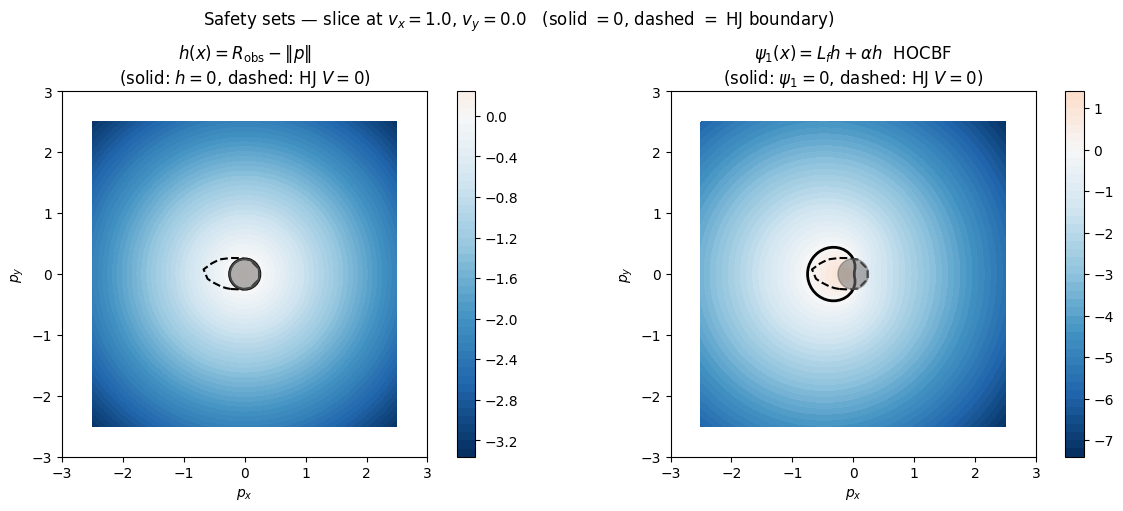

In [15]:
fig_viz, axes_viz = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')

_titles = [
    r'$h(x) = R_{\rm obs} - \|p\|$'
    f'\n(solid: $h=0$, dashed: HJ $V=0$)',
    r'$\psi_1(x) = L_f h + \alpha h$  HOCBF'
    f'\n(solid: $\psi_1=0$, dashed: HJ $V=0$)',
]

for ax, val_grid, title in zip(axes_viz, [h_viz, B_viz], _titles):
    lim = float(np.abs(val_grid).max()) * 1.01
    cf  = ax.contourf(px_g, py_g, val_grid, levels=50,
                      cmap='RdBu_r', vmin=-lim, vmax=lim)
    # CBF zero-level-set (solid black)
    ax.contour(px_g, py_g, val_grid, levels=[0.0], colors='k', linewidths=2.0)
    # HJ zero-level-set (dashed black)
    ax.contour(_px_c, _py_c, hj_slice.T, levels=[0.0],
               colors='k', linewidths=1.5, linestyles='--')
    ax.add_patch(Circle((0, 0), R_OBS,
                        facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=3))
    ax.set_xlabel(r'$p_x$')
    ax.set_ylabel(r'$p_y$')
    ax.set_aspect('equal')
    ax.set_title(title)
    plt.colorbar(cf, ax=ax)

fig_viz.suptitle(
    rf'Safety sets — slice at $v_x = {VX_SLICE}$, $v_y = {VY_SLICE}$   '
    r'(solid $= 0$, dashed $=$ HJ boundary)')
plt.show()

In [16]:
def _guardian_step(carry, step_idx, goal):
    x, bias      = carry
    xhat         = x + bias
    lo, hi       = _box_bounds(xhat)
    state_bounds = hj.sets.Box(lo, hi)
    u_nom        = nom_pol_goto(xhat, goal)
    _, u_star, _, val_filter, _, _, _, _ = guardian_filter.ua_filter_best_u(
        u_nom, state_bounds, num_states=3, delta=0.1)
    u = jnp.where(val_filter < 0.0, u_star, u_nom)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

In [34]:
import cvxpy as cp

_eps_arr        = np.array(STATE_EPS)
_tight_const_np = float(np.sum(_eps_arr * (_L_Lf_dim + _L_ah_dim)))   # constant part
_tight_LG_np    = float(np.sum(_eps_arr * _L_LG_dim))     

def rollout_mrcbf_cvxpy(x0, bias):
    """Reference rollout — slow, not for MC. Use to validate _mrcbf_step."""
    n_steps = 400
    xs, xhats = [], []
    x = np.asarray(x0)
    b = np.asarray(bias)
    for _ in range(n_steps):
        xhat = x + b
        h_B  = float(B_hocbf(xhat)[0])
        J_B  = np.asarray(jax.jacobian(B_hocbf)(xhat))[0]
        f_xh = np.asarray(f(xhat))
        G_xh = np.asarray(G(xhat))
        Lf_B = float(J_B @ f_xh)
        Lg_B = J_B @ G_xh
        u_n  = np.asarray(nom_pol_goto(xhat))

        u, d = cp.Variable(2), cp.Variable(nonneg=True)
        cons = [
            Lf_B + Lg_B @ u + ALPHA_QP * h_B
            <= -_tight_const_np - _tight_LG_np * cp.norm(u, 2) + d,
            u >= np.asarray(u_lb),
            u <= np.asarray(u_ub),
        ]
        cp.Problem(cp.Minimize(0.5*cp.sum_squares(u - u_n) + 10.0*d**2),
                   cons).solve(solver=cp.CLARABEL)

        u_val = np.asarray(u.value)
        xs.append(x.copy()); xhats.append(xhat.copy())
        x = x + DT * (np.asarray(f(x)) + np.asarray(G(x)) @ u_val)
    return np.stack(xs), np.stack(xhats)



## Demo rollout — single trajectory

In [ ]:
print('Available devices:', jax.devices())                                                                                                
print('Default backend:', jax.default_backend())                                                                                          
print('Sample array device:', jnp.ones(3).sharding)

# Named rollout functions — goal captured in closure, signature (x0, bias) for vmap
rollout_nom          = _make_rollout(_nom_step)
rollout_cbf          = _make_rollout(_cbf_step)
rollout_rcbf         = _make_rollout(_rcbf_step)
rollout_duality      = _make_rollout(_duality_step)
rollout_rcbf_02      = _make_rollout(_make_rcbf_fixed_step(0.2))
rollout_rcbf_10      = _make_rollout(_make_rcbf_fixed_step(1.0))
rollout_nmr_pretrain = _make_rollout(_nmr_pretrain_step)
rollout_nmr_finetune = _make_rollout(_nmr_finetune_step)
rollout_guardian     = _make_rollout(_guardian_step)
rollout_lfhwc        = _make_rollout(_lfhwc_step)
rollout_mrcbf        = _make_rollout(_mrcbf_step)

_ALL_ROLLOUTS = [
    ('Nominal',        rollout_nom),
    ('CBF',            rollout_cbf),
    ('R-CBF (0.2)',    rollout_rcbf_02),
    ('R-CBF (1.0)',    rollout_rcbf_10),
    ('R-CBF-QP',       rollout_rcbf),
    ('GUARDIAN',       rollout_guardian),
    ('Duality CBF',    rollout_duality),
    ('PSHR-CBF',       rollout_lfhwc),
    ('NMR-CBF',        rollout_nmr_pretrain),
    ('NMR-CBF (RL)',   rollout_nmr_finetune),  
]

X0_DEMO   = jnp.array([-1.5, 0.0, 0.1, 0.0])
BIAS_DEMO = jnp.array([-STATE_EPS[0], STATE_EPS[1], STATE_EPS[2], -STATE_EPS[3]])  # bias towards obstacle to test safety

# --- Precompile all rollouts so MC timing is fair ---
print('Precompiling rollouts...')
for name, fn in _ALL_ROLLOUTS:
    jax.block_until_ready(fn(X0_DEMO, BIAS_DEMO))
    print(f'  {name:<16}  compiled')

# --- Demo run ---
print('\nDemo rollout (obstacle violated?):')
results = {}
for name, fn in _ALL_ROLLOUTS:
    # if name == 'MR-CBF':
    #     print(f'  {name:<16}  computing (this may take ~30s)...')
    #     xs, xhats = rollout_mrcbf_cvxpy(X0_DEMO, BIAS_DEMO)
    # else:
    xs, xhats = jax.device_get(fn(X0_DEMO, BIAS_DEMO))
    results[name] = dict(xs=xs, xhats=xhats)
    viol = bool(np.any(xs[:, 0]**2 + xs[:, 2]**2 < R_OBS**2 - 1e-3))
    print(f'  {name:<16}  {viol}')


Available devices: [cuda(id=0), cuda(id=1)]
Default backend: gpu
Sample array device: SingleDeviceSharding(device=cuda(id=0))
Precompiling rollouts...
  Nominal           compiled
  CBF               compiled
  R-CBF (0.2)       compiled
  R-CBF (1.0)       compiled
  R-CBF-QP          compiled
  GUARDIAN          compiled
  Duality CBF       compiled
  NMR-CBF           compiled
  NMR-CBF (RL)      compiled
  PSHR-CBF          compiled

Demo rollout (obstacle violated?):
  Nominal           True
  CBF               False
  R-CBF (0.2)       False
  R-CBF (1.0)       False
  R-CBF-QP          False
  GUARDIAN          False
  Duality CBF       False
  NMR-CBF           False
  NMR-CBF (RL)      False
  PSHR-CBF          False


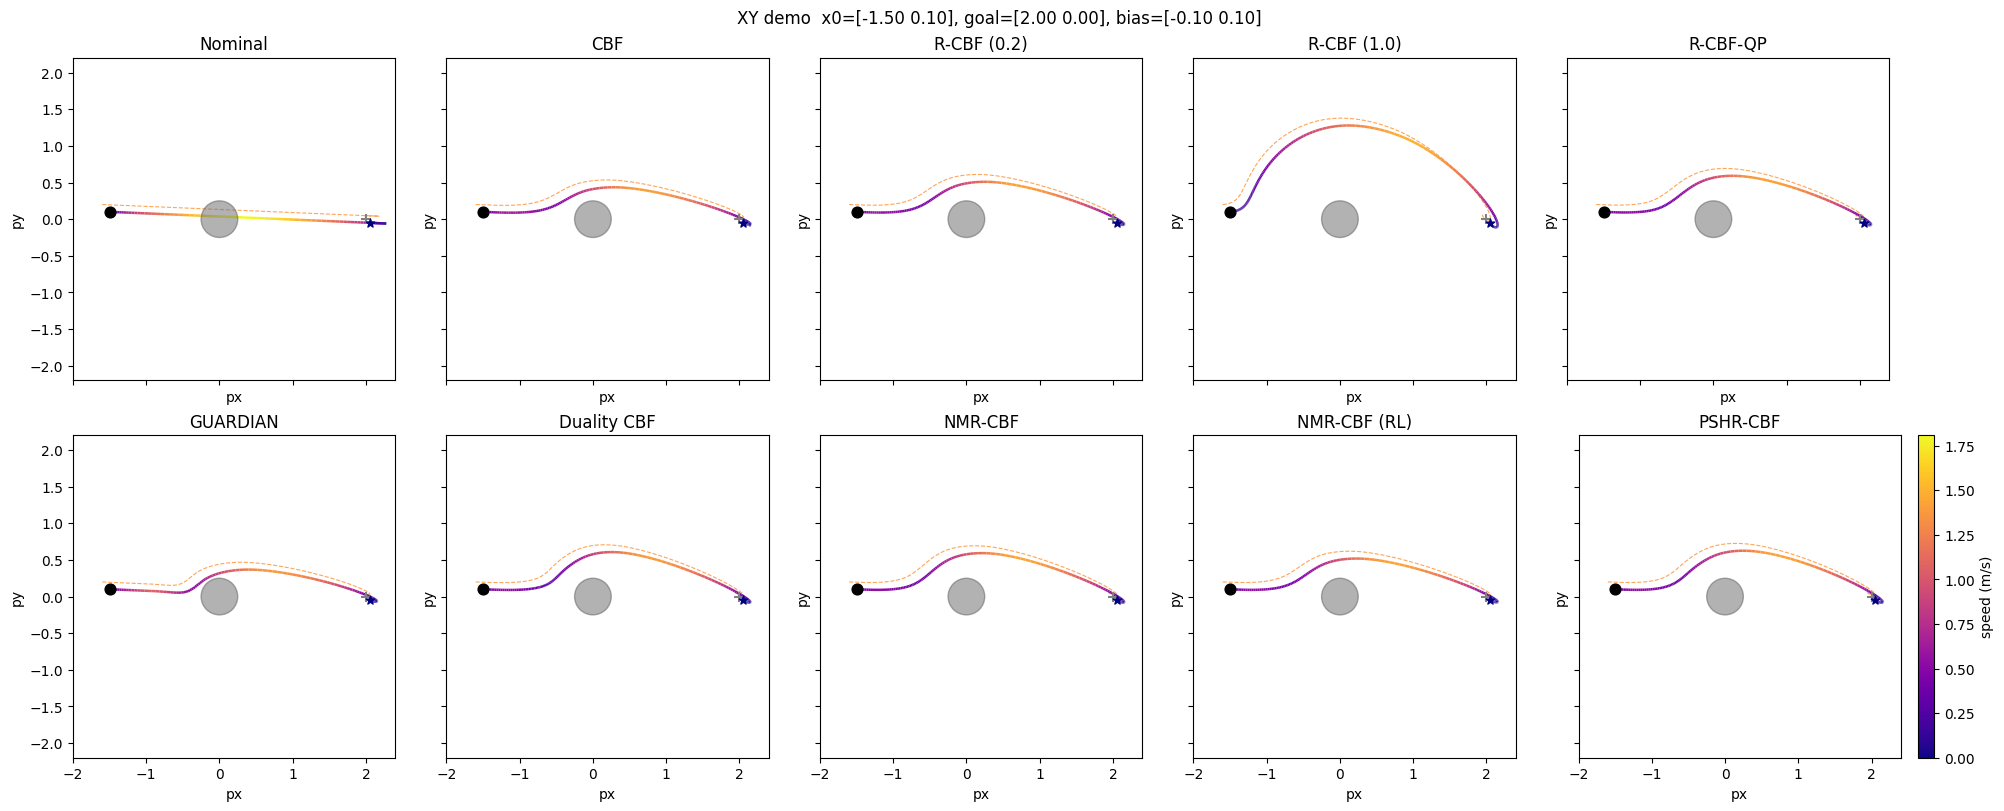

: 

In [ ]:
_XLIM = (-2.0, 2.4)
_YLIM = (-2.2, 2.2)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), layout='constrained',
                          sharex=True, sharey=True)
axes = axes.flatten()

# Speed at each timestep; vmax clipped to the visible window so off-screen
# high-speed segments (e.g. R-CBF-QP after obstacle) don't wash out the scale.
_all_speeds = []
_vmax_in_window = []
for d in results.values():
    xs    = d['xs']
    speed = np.sqrt(xs[:,1]**2 + xs[:,3]**2)
    _all_speeds.append(speed)
    in_window = (np.abs(xs[:,0]) <= _XLIM[1]) & (np.abs(xs[:,2]) <= _YLIM[1])
    if in_window.any():
        _vmax_in_window.append(float(speed[in_window].max()))

_speed_norm = plt.Normalize(0, max(_vmax_in_window))

lc_last = None
for ax, (name, d), speed in zip(axes, results.items(), _all_speeds):
    xs, xhats = d['xs'], d['xhats']
    pts  = np.stack([xs[:,0], xs[:,2]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='plasma', norm=_speed_norm, lw=1.8, zorder=3)
    lc.set_array((speed[:-1] + speed[1:]) / 2)   # midpoint speed per segment
    ax.add_collection(lc)
    ax.plot(xhats[:,0], xhats[:,2], color='C1', lw=0.8, ls='--', alpha=0.7)
    ax.scatter(xs[0,0],  xs[0,2],  s=60, color='k',    zorder=6)
    ax.scatter(xs[-1,0], xs[-1,2], s=40, color='navy', marker='*', zorder=6)
    ax.scatter(*GOAL_MC[:2], s=50, color='gray', marker='+', zorder=5)
    ax.add_patch(Circle((0,0), R_OBS, facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=4))
    ax.set_xlim(*_XLIM); ax.set_ylim(*_YLIM); ax.set_aspect('equal')
    
    ax.set_xlabel('px'); ax.set_ylabel('py'); ax.set_title(name)
    lc_last = lc

fig.colorbar(lc_last, ax=axes[-1], label='speed (m/s)')
_x0_px_py   = [float(X0_DEMO[0]),   float(X0_DEMO[2])]
_bias_px_py = [float(BIAS_DEMO[0]), float(BIAS_DEMO[2])]
fig.suptitle(
    f"XY demo  x0={np.array2string(np.array(_x0_px_py), formatter={'float_kind':lambda x: f'{x:.2f}'})}, "
    f"goal={np.array2string(np.array(GOAL_MC[:2]), formatter={'float_kind':lambda x: f'{x:.2f}'})}, "
    f"bias={np.array2string(np.array(_bias_px_py), formatter={'float_kind':lambda x: f'{x:.2f}'})}"
)
plt.show()

In [ ]:
# ── MC XY trajectory spaghetti — data collection ────────────────────────────
N_PLOT = 200   # subset of MC samples; set to N_MC for all 1000
_rng_sub    = np.random.default_rng(42)
_sub_idx    = _rng_sub.choice(N_MC, size=N_PLOT, replace=False)
_x0s_sub    = x0s[_sub_idx]
_biases_sub = biases[_sub_idx]

_PLOT_ORDER = [
    'GUARDIAN', 'CBF', 'R-CBF (0.2)', 'R-CBF (1.0)',
    'Duality CBF', 'R-CBF-QP', 'PSHR-CBF', 'NMR-CBF (RL)', 'NMR-CBF'
]
_name_to_rollout = dict(_ALL_ROLLOUTS)

print(f'Running {N_PLOT} rollouts per policy...')
_sub_trajs = {}
_GUARDIAN_BATCH = 25
for _name in _PLOT_ORDER:
    _fn = _name_to_rollout[_name]
    if _name == 'GUARDIAN':
        _chunks = []
        for _i in range(0, N_PLOT, _GUARDIAN_BATCH):
            _sl = slice(_i, _i + _GUARDIAN_BATCH)
            _xs_c, _ = jax.device_get(jax.vmap(_fn)(_x0s_sub[_sl], _biases_sub[_sl]))
            _chunks.append(np.array(_xs_c))
        _sub_trajs[_name] = np.concatenate(_chunks)
    else:
        _xs_all, _ = jax.device_get(jax.jit(jax.vmap(_fn))(_x0s_sub, _biases_sub))
        _sub_trajs[_name] = np.array(_xs_all)
    print(f'  {_name} done')


Running 200 rollouts per policy...
  GUARDIAN done
  CBF done
  R-CBF (0.2) done
  R-CBF (1.0) done
  Duality CBF done
  R-CBF-QP done
  PSHR-CBF done
  NMR-CBF (RL) done
  NMR-CBF done


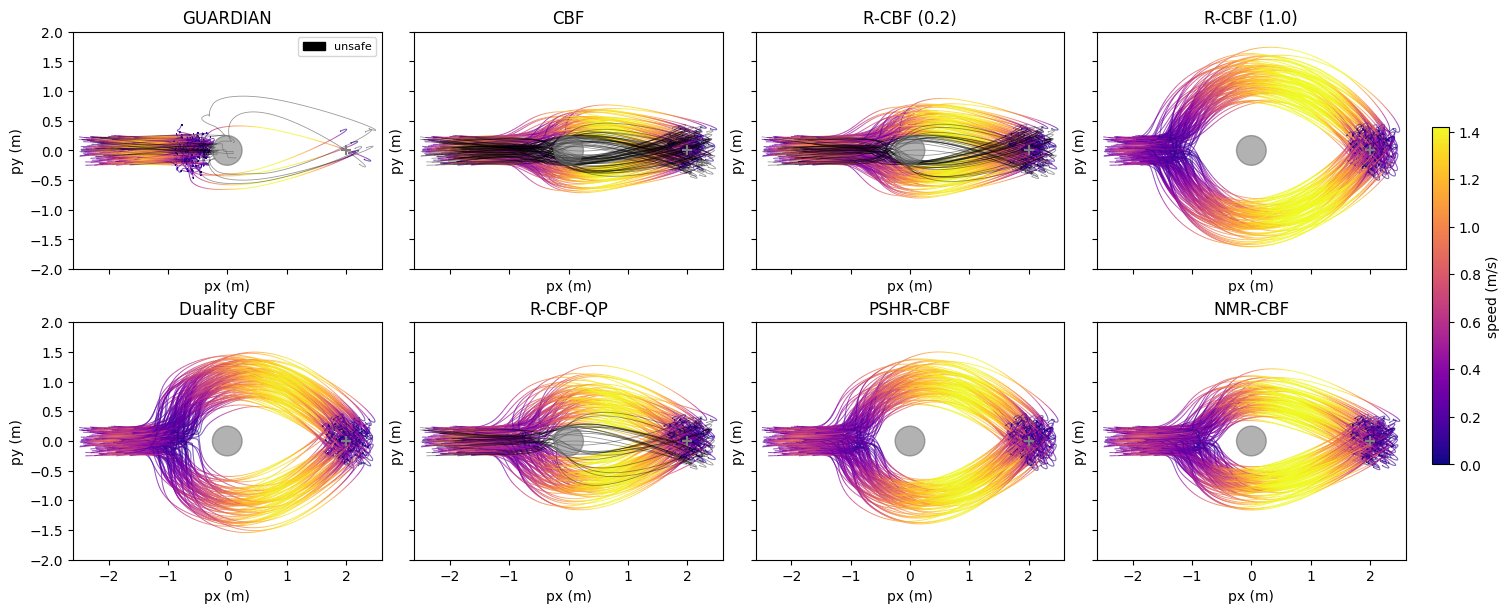

In [ ]:
_XLIM = (-2.6, 2.6)
_YLIM = (-2.0, 2.0)

# Violation flags
_sub_viols = {}
_h_sub = jax.jit(jax.vmap(jax.vmap(h_raw)))
for _name, _xs in _sub_trajs.items():
    _h_all = np.array(_h_sub(jnp.array(_xs)))
    _sub_viols[_name] = _h_all.max(axis=(1, 2)) > 0

# Global speed norm across all safe trajectories
_all_safe_speeds = np.concatenate([
    np.sqrt(_sub_trajs[n][~_sub_viols[n], :, 1]**2 +
            _sub_trajs[n][~_sub_viols[n], :, 3]**2).ravel()
    for n in _PLOT_ORDER if (~_sub_viols[n]).any()
])
_speed_vmax = float(np.percentile(_all_safe_speeds, 99))
_speed_norm = plt.Normalize(0, _speed_vmax)
_cmap = plt.cm.plasma

fig, axes = plt.subplots(2, 4, figsize=(15, 6), layout='constrained',
                          sharex=True, sharey=True)
axes = axes.flatten()

for ax, _name in zip(axes, _PLOT_ORDER):
    _xs   = _sub_trajs[_name]    # (N_PLOT, T+1, 4)
    _viol = _sub_viols[_name]    # (N_PLOT,) bool
    _speed = np.sqrt(_xs[:, :, 1]**2 + _xs[:, :, 3]**2)       # (N_PLOT, T+1)
    _seg_spd = 0.5 * (_speed[:, :-1] + _speed[:, 1:])          # (N_PLOT, T)

    # Safe traces — single LineCollection; alpha embedded in RGBA so colorbar stays opaque
    _safe = ~_viol
    if _safe.any():
        _sx   = _xs[_safe]                # (n_safe, T+1, 4)
        _pts  = np.stack([_sx[:, :, 0], _sx[:, :, 2]], axis=2)  # (n_safe, T+1, 2)  px,py
        _segs = np.concatenate([_pts[:, :-1, None, :], _pts[:, 1:, None, :]], axis=2)
        _segs = _segs.reshape(-1, 2, 2)             # (n_safe*T, 2, 2)
        _cols = _seg_spd[_safe].ravel()
        _rgba = _cmap(_speed_norm(_cols))            # alpha=1 RGBA from colormap
        _rgba[:, 3] = 0.8                            # embed alpha; colorbar unaffected
        lc = LineCollection(_segs, colors=_rgba, lw=0.7, zorder=3)
        ax.add_collection(lc)

    # Unsafe traces — black
    if _viol.any():
        ax.plot(_xs[_viol, :, 0].T, _xs[_viol, :, 2].T,
                color='k', lw=0.6, alpha=0.4, zorder=4)

    ax.add_patch(Circle((0, 0), R_OBS, facecolor='0.45', edgecolor='0.4',
                         alpha=0.55, zorder=5))
    ax.scatter(*np.array(GOAL_MC)[[0, 2]], s=50, color='gray', marker='+', zorder=6)
    ax.set_xlim(*_XLIM); ax.set_ylim(*_YLIM); ax.set_aspect('equal')
    ax.set_xlabel('px (m)'); ax.set_ylabel('py (m)')
    if _name != 'NMR-CBF (RL)' and _name != 'NMR-CBF':
        ax.set_title(_name)
    elif _name == 'NMR-CBF (RL)':
        ax.set_title('NMR-CBF')
    else:
        ax.set_title('NMR-CBF (pretrain)')
    # ax.set_title(_name)

# Colorbar spanning all rows via ScalarMappable (alpha=1) across all axes
_sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_speed_norm)
_sm.set_array([])
fig.colorbar(_sm, ax=axes.tolist(), label='speed (m/s)', shrink=0.6, pad=0.02)

import matplotlib.patches as mpatches
_leg = [mpatches.Patch(color='k', label='unsafe')]
axes[0].legend(handles=_leg, fontsize=8, loc='upper right')
# fig.suptitle(
#     f'MC XY trajectories ({N_PLOT}/{N_MC} samples per policy, '
#     f'ε={float(STATE_EPS[0]):.2f})  — color = speed (m/s)'
# )
plt.show()


## Monte Carlo safety evaluation

In [18]:
GOAL_TOL  = 0.1   # metres — final position tolerance
VEL_TOL   = 0.1   # m/s   — final speed tolerance
N_MC      = 1_000
MC_BOUNDS = np.array([[-2.5, -0.25], [-1.5, 0.25]])  # row0: [px_min, py_min]; row1: [px_max, py_max]
# MC_BOUNDS = np.array([[-2.0, -0.25], [-1.0, 0.25]])

_eps_px_val     = float(STATE_EPS[0])
_mc_cache_file  = _mc_results_dir / f'mc_eps_{_eps_px_val:.3f}.pkl'

# ICs always generated from the same seed so they match cached violation arrays
rng_mc = jr.PRNGKey(42)
rng_mc, rng_ic, rng_bias = jr.split(rng_mc, 3)
x0pos  = jr.uniform(rng_ic,   (N_MC, 2), minval=MC_BOUNDS[0], maxval=MC_BOUNDS[1])
x0s    = jnp.stack([x0pos[:, 0], jnp.zeros(N_MC),
                    x0pos[:, 1], jnp.zeros(N_MC)], axis=1)
biases = jr.uniform(rng_bias, (N_MC, 4), minval=-STATE_EPS, maxval=STATE_EPS)
print(f'x0s {x0s.shape}  biases {biases.shape}')

mc_results     = {}
mc_goals       = {}
mc_viols       = {}
mc_reached     = {}
mc_reach_times = {}

_loaded_from_cache = False
if _mc_cache_file.exists():
    with open(_mc_cache_file, 'rb') as _f:
        _cached = pickle.load(_f)
    if 'violation_array' in _cached and 'reached_array' in _cached:
        print(f'Loading cached MC results from {_mc_cache_file}')
        N_MC       = _cached['N_MC']
        mc_viols       = {k: np.array(v, dtype=bool) for k, v in _cached['violation_array'].items()}
        mc_reached     = {k: np.array(v, dtype=bool) for k, v in _cached['reached_array'].items()}
        mc_reach_times = {k: np.array(v)             for k, v in _cached.get('reach_time_array', {}).items()}
        mc_results = _cached['violation_rates']
        mc_goals   = _cached['goal_rates']
        _loaded_from_cache = True
        for name in mc_viols:
            print(f'  {name:<16}  viol={mc_results[name]:.0%}  goal={mc_goals[name]:.0%}')
    else:
        print('Cache file exists but missing arrays — will re-run.')

if not _loaded_from_cache:
    _GUARDIAN_BATCH = 25
    _guardian_vmap  = jax.jit(jax.vmap(rollout_guardian))

    def _mc_guardian(x0s_in, biases_in):
        n = x0s_in.shape[0]
        xs_chunks, xh_chunks = [], []
        for i in range(0, n, _GUARDIAN_BATCH):
            sl = slice(i, i + _GUARDIAN_BATCH)
            xs_c, xh_c = _guardian_vmap(x0s_in[sl], biases_in[sl])
            xs_chunks.append(xs_c); xh_chunks.append(xh_c)
            print(f'    GUARDIAN batch {i//_GUARDIAN_BATCH + 1}/{-(-n//_GUARDIAN_BATCH)}')
        return jnp.concatenate(xs_chunks), jnp.concatenate(xh_chunks)

    _mc_fns = [
        ('Nominal',        jax.jit(jax.vmap(rollout_nom))),
        ('CBF',            jax.jit(jax.vmap(rollout_cbf))),
        ('R-CBF-QP',       jax.jit(jax.vmap(rollout_rcbf))),
        ('Duality CBF',    jax.jit(jax.vmap(rollout_duality))),
        ('R-CBF (0.2)',    jax.jit(jax.vmap(rollout_rcbf_02))),
        ('R-CBF (1.0)',    jax.jit(jax.vmap(rollout_rcbf_10))),
        ('PSHR-CBF',       jax.jit(jax.vmap(rollout_lfhwc))),
        ('MR-CBF',         jax.jit(jax.vmap(rollout_mrcbf))),
        ('NMR-CBF',        jax.jit(jax.vmap(rollout_nmr_pretrain))),
        ('NMR-CBF (RL)',   jax.jit(jax.vmap(rollout_nmr_finetune))),
        ('GUARDIAN',       _mc_guardian),
    ]

    _h_mc = jax.jit(jax.vmap(jax.vmap(h_raw)))  # (N, T+1, 4) → (N, T+1, 1)

    print(f'Running MC (N={N_MC}, T={T*DT:.0f}s, pos_tol={GOAL_TOL}m, vel_tol={VEL_TOL}m/s)...')
    for name, mc_fn in _mc_fns:
        xs_all, xhats_all = jax.device_get(mc_fn(x0s, biases))   # (N, T+1, 4), (N, T, 4)
        # Safety check on true state
        h_all  = np.array(_h_mc(jnp.array(xs_all)))
        viols  = h_all.max(axis=(1, 2)) > 0
        # Goal check on estimated state — controller only knows xhat
        px_f, vx_f = xhats_all[:, -1, 0], xhats_all[:, -1, 1]
        py_f, vy_f = xhats_all[:, -1, 2], xhats_all[:, -1, 3]
        dist_f  = np.sqrt((px_f - float(GOAL_MC[0]))**2 + (py_f - float(GOAL_MC[2]))**2)
        vx_f = xs_all[:, -1, 1]
        vy_f = xs_all[:, -1, 3]
        speed_f = np.sqrt(vx_f**2 + vy_f**2)
        # reached = (dist_f <= GOAL_TOL) & (speed_f <= VEL_TOL)
        reached = (px_f >= 0) & (speed_f <= VEL_TOL)
        mc_viols[name]   = viols
        mc_reached[name] = reached
        mc_results[name] = float(viols.mean())
        mc_goals[name]   = float(reached.mean())
        # Time-to-goal on true state (consistent with safety check)
        px_t    = xs_all[:, :, 0]
        spd_t   = np.sqrt(xs_all[:, :, 1]**2 + xs_all[:, :, 3]**2)
        in_goal = (px_t >= 0) & (spd_t <= VEL_TOL)  # (N, T+1)
        ever    = in_goal.any(axis=1)
        first_t = np.argmax(in_goal, axis=1)          # 0 where never reached
        mc_reach_times[name] = np.where(ever, first_t * DT, np.nan)
        print(f'  {name:<16}  viol={mc_results[name]:.0%} ({int(viols.sum())}/{N_MC})'
              f'  goal={mc_goals[name]:.0%} ({int(reached.sum())}/{N_MC})'
              f'  t_reach_mean={float(np.nanmean(mc_reach_times[name])):.1f}s')

x0s (1000, 4)  biases (1000, 4)
Loading cached MC results from /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_dbint2d/policies/obs0.25/mc_results/full_scaling2x1_combined/mc_eps_0.300.pkl
  Nominal           viol=98%  goal=100%
  CBF               viol=36%  goal=100%
  R-CBF-QP          viol=10%  goal=100%
  NMR-CBF           viol=0%  goal=100%
  Duality CBF       viol=0%  goal=98%
  R-CBF (0.2)       viol=19%  goal=100%
  R-CBF (1.0)       viol=0%  goal=100%
  GUARDIAN          viol=10%  goal=5%
  NMR-CBF (RL)      viol=0%  goal=100%
  PSHR-CBF          viol=0%  goal=100%


In [18]:
# Save freshly computed MC results so the cell above can load from cache on re-run.
if not _loaded_from_cache:
    _mc_results_dir.mkdir(parents=True, exist_ok=True)
    _mc_save = {
        'STATE_EPS':       np.array(STATE_EPS),
        'N_MC':            N_MC,
        'px0':             np.array(x0s[:, 0]),
        'py0':             np.array(x0s[:, 2]),
        'violation_rates': mc_results,
        'goal_rates':      mc_goals,
        'violation_array':  {k: v.tolist() for k, v in mc_viols.items()},
        'reached_array':    {k: v.tolist() for k, v in mc_reached.items()},
        'reach_time_array': {k: v.tolist() for k, v in mc_reach_times.items()},
    }
    with open(_mc_cache_file, 'wb') as _f:
        pickle.dump(_mc_save, _f)
    print(f'Saved MC results to {_mc_cache_file}')
else:
    print(f'Results loaded from cache ({_mc_cache_file.name}) — nothing to save.')

Saved MC results to /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_dbint2d/policies/obs0.25/mc_results/full_scaling2x1_combined/mc_eps_0.050.pkl


## GUARDIAN backfill

Runs GUARDIAN on every cached MC file in `_mc_results_dir` that is missing GUARDIAN results, then updates the pickle in-place.

`STATE_EPS` is read directly from each pickle so the epsilon regime (fixed-velocity, full-scaling, etc.) is handled automatically — no need to special-case directory names.  The same JAX seed is used to reproduce the exact biases that were generated when the other policies ran.

In [37]:
# ── Backfill GUARDIAN results into existing MC cache files ───────────────────
# Safe to re-run: files that already contain 'GUARDIAN' are skipped.
#
# GUARDIAN's step function closes over STATE_EPS via _box_bounds, so the JIT
# kernel has eps baked in.  We create a fresh step + rollout per file so JAX
# recompiles with the correct eps each time.
import pickle
from pathlib import Path

FORCE_BACKFILL = True   # True ⇒ overwrite existing entries

_bf_files = sorted(_mc_results_dir.glob('mc_eps_*.pkl'))
if not _bf_files:
    print(f'No MC cache files found in {_mc_results_dir}')
else:
    _h_bf = jax.jit(jax.vmap(jax.vmap(h_raw)))
    _GUARDIAN_BATCH_BF = 25

    def _make_guardian_step_bf(state_eps):
        """Guardian step that closes over state_eps — forces recompile per eps."""
        def _step(carry, step_idx, goal):
            x, bias      = carry
            xhat         = x + bias
            lo           = xhat - state_eps
            hi           = xhat + state_eps
            state_bounds = hj.sets.Box(lo, hi)
            u_nom        = nom_pol_goto(xhat, goal)
            _, u_star, _, val_filter, _, _, _, _ = guardian_filter.ua_filter_best_u(
                u_nom, state_bounds, num_states=3, delta=0.1)
            u = jnp.where(val_filter < 0.0, u_star, u_nom)
            return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)
        return _step

    for fp in _bf_files:
        with open(fp, 'rb') as fh:
            data = pickle.load(fh)

        if not FORCE_BACKFILL and 'GUARDIAN' in data.get('violation_array', {}):
            print(f'  skipping {fp.name} — GUARDIAN already present')
            continue

        bf_N_MC       = data['N_MC']
        bf_STATE_EPS  = jnp.array(data['STATE_EPS'])
        bf_px0        = np.array(data['px0'])
        bf_py0        = np.array(data['py0'])
        print(f'{fp.name}: compiling GUARDIAN for STATE_EPS={np.array(bf_STATE_EPS)}...')

        # Fresh rollout compiled for this file's eps
        bf_rollout    = _make_rollout(_make_guardian_step_bf(bf_STATE_EPS))
        bf_vmap       = jax.jit(jax.vmap(bf_rollout))
        # Warm-up compile before the batch loop
        _dummy_x0  = jnp.zeros((1, 4))
        _dummy_b   = jnp.zeros((1, 4))
        jax.block_until_ready(bf_vmap(_dummy_x0, _dummy_b))
        print(f'  compiled, running {bf_N_MC} rollouts...')

        # Reconstruct x0s (velocities always zero at start)
        bf_x0s = jnp.stack([jnp.array(bf_px0), jnp.zeros(bf_N_MC),
                             jnp.array(bf_py0), jnp.zeros(bf_N_MC)], axis=1)

        # Reproduce biases from the same seed used in the MC cell
        _, _, _rng_bias_bf = jr.split(jr.PRNGKey(42), 3)
        bf_biases = jr.uniform(_rng_bias_bf, (bf_N_MC, 4),
                               minval=-bf_STATE_EPS, maxval=bf_STATE_EPS)

        # Batched rollout
        xs_chunks, xh_chunks = [], []
        for i in range(0, bf_N_MC, _GUARDIAN_BATCH_BF):
            sl = slice(i, i + _GUARDIAN_BATCH_BF)
            xs_c, xh_c = bf_vmap(bf_x0s[sl], bf_biases[sl])
            xs_chunks.append(xs_c); xh_chunks.append(xh_c)
            print(f'    batch {i//_GUARDIAN_BATCH_BF + 1}/{-(-bf_N_MC//_GUARDIAN_BATCH_BF)}', end='\r')
        print()
        xs_all, xhats_all = jax.device_get(
            (jnp.concatenate(xs_chunks), jnp.concatenate(xh_chunks)))

        # Safety, goal, reach-time (matches MC cell logic exactly)
        h_all   = np.array(_h_bf(jnp.array(xs_all)))
        viols   = h_all.max(axis=(1, 2)) > 0
        px_f    = xhats_all[:, -1, 0]
        speed_f = np.sqrt(xs_all[:, -1, 1]**2 + xs_all[:, -1, 3]**2)
        reached = (px_f >= 0) & (speed_f <= VEL_TOL)
        in_goal = ((xs_all[:, :, 0] >= 0) &
                   (np.sqrt(xs_all[:, :, 1]**2 + xs_all[:, :, 3]**2) <= VEL_TOL))
        ever    = in_goal.any(axis=1)
        first_t = np.argmax(in_goal, axis=1)
        reach_times = np.where(ever, first_t * DT, np.nan)

        # Write GUARDIAN entries into the existing dict
        data['violation_array']['GUARDIAN']  = viols.tolist()
        data['reached_array']['GUARDIAN']    = reached.tolist()
        data.setdefault('reach_time_array', {})['GUARDIAN'] = reach_times.tolist()
        data['violation_rates']['GUARDIAN']  = float(viols.mean())
        data['goal_rates']['GUARDIAN']       = float(reached.mean())

        with open(fp, 'wb') as fh:
            pickle.dump(data, fh)
        print(('  {:<16}  viol={:.0%} ({}/{})  goal={:.0%} ({}/{})'
               '  t_reach_mean={:.1f}s  -> saved {}').format(
            'GUARDIAN', float(viols.mean()), int(viols.sum()), bf_N_MC,
            float(reached.mean()), int(reached.sum()), bf_N_MC,
            float(np.nanmean(reach_times)), fp.name))

    print('Backfill complete.')


mc_eps_0.000.pkl: compiling GUARDIAN for STATE_EPS=[0. 0. 0. 0.]...
  compiled, running 1000 rollouts...
    batch 40/40
  GUARDIAN          viol=0% (0/1000)  goal=100% (1000/1000)  t_reach_mean=4.6s  -> saved mc_eps_0.000.pkl
mc_eps_0.050.pkl: compiling GUARDIAN for STATE_EPS=[0.05  0.025 0.05  0.025]...
  compiled, running 1000 rollouts...
    batch 40/40
  GUARDIAN          viol=9% (90/1000)  goal=98% (985/1000)  t_reach_mean=5.0s  -> saved mc_eps_0.050.pkl
mc_eps_0.100.pkl: compiling GUARDIAN for STATE_EPS=[0.1  0.05 0.1  0.05]...
  compiled, running 1000 rollouts...
    batch 40/40
  GUARDIAN          viol=8% (82/1000)  goal=93% (926/1000)  t_reach_mean=5.2s  -> saved mc_eps_0.100.pkl
mc_eps_0.200.pkl: compiling GUARDIAN for STATE_EPS=[0.2 0.1 0.2 0.1]...
  compiled, running 1000 rollouts...
    batch 40/40
  GUARDIAN          viol=18% (175/1000)  goal=17% (167/1000)  t_reach_mean=7.2s  -> saved mc_eps_0.200.pkl
mc_eps_0.300.pkl: compiling GUARDIAN for STATE_EPS=[0.3  0.15 0.3  0.

In [32]:
# ── Backfill PSHR-CBF results into existing MC cache files ───────────────────
# Safe to re-run: files that already containing 'PSHR-CBF' are skipped.
#
# _lfhwc_step closes over STATE_EPS via _box_bounds, so we create a fresh step
# per file (forcing JAX to recompile with the correct eps each time).
import pickle
from pathlib import Path

FORCE_BACKFILL = True   # True ⇒ overwrite existing entries

_bf_files = sorted(_mc_results_dir.glob('mc_eps_*.pkl'))
if not _bf_files:
    print(f'No MC cache files found in {_mc_results_dir}')
else:
    _h_bf = jax.jit(jax.vmap(jax.vmap(h_raw)))

    def _make_pshr_step_bf(state_eps):
        """PSHR-CBF step that closes over state_eps — forces recompile per eps."""
        def _step(carry, step_idx, goal):
            x, bias   = carry
            xhat      = x + bias
            lo        = xhat - state_eps
            hi        = xhat + state_eps
            u_nom     = nom_pol_goto(xhat, goal)
            opt_key   = jr.fold_in(BASE_KEY, step_idx)

            h_nom  = B_hocbf(xhat)
            J_nom  = jax.jacobian(B_hocbf)(xhat)
            Lf_nom = J_nom @ f(xhat)

            nh   = h_nom.shape[0]
            keys = jr.split(opt_key, nh)

            def worst_i(i, k):
                _, x_wc = proj_grad_max_box(
                    lambda xi: (jax.jacobian(B_hocbf)(xi) @ f(xi) + ALPHA_QP * B_hocbf(xi))[i],
                    lo, hi, n_restarts=4, n_steps=25, lr=0.05, key=k)
                h_wc_i  = B_hocbf(x_wc)[i]
                Lf_wc_i = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
                return h_wc_i, Lf_wc_i

            h_wc, Lf_wc = jax.vmap(worst_i)(jnp.arange(nh), keys)
            phi_oracle = (Lf_wc + ALPHA_QP * h_wc) - (Lf_nom + ALPHA_QP * h_nom)
            u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_nom + phi_oracle / ALPHA_QP, J_nom,
                                    f(xhat), G(xhat), u_nom, relax_eps2=0.1)
            return (x + DT * (f(x) + G(x) @ u), bias), (x, xhat)
        return _step

    for fp in _bf_files:
        with open(fp, 'rb') as fh:
            data = pickle.load(fh)

        if not FORCE_BACKFILL and 'PSHR-CBF' in data.get('violation_array', {}):
            print(f'  skipping {fp.name} — PSHR-CBF already present')
            continue

        bf_N_MC      = data['N_MC']
        bf_STATE_EPS = jnp.array(data['STATE_EPS'])
        bf_px0       = np.array(data['px0'])
        bf_py0       = np.array(data['py0'])
        print(f'{fp.name}: compiling PSHR-CBF for STATE_EPS={np.array(bf_STATE_EPS)}...')

        # Fresh rollout compiled for this file's eps
        bf_rollout = _make_rollout(_make_pshr_step_bf(bf_STATE_EPS))
        bf_vmap    = jax.jit(jax.vmap(bf_rollout))
        jax.block_until_ready(bf_vmap(jnp.zeros((1, 4)), jnp.zeros((1, 4))))
        print(f'  compiled, running {bf_N_MC} rollouts...')

        # Reconstruct x0s and biases from the same seeds used in the MC cell
        bf_x0s = jnp.stack([jnp.array(bf_px0), jnp.zeros(bf_N_MC),
                             jnp.array(bf_py0), jnp.zeros(bf_N_MC)], axis=1)
        _, _, _rng_bias_bf = jr.split(jr.PRNGKey(42), 3)
        bf_biases = jr.uniform(_rng_bias_bf, (bf_N_MC, 4),
                               minval=-bf_STATE_EPS, maxval=bf_STATE_EPS)

        xs_all, xhats_all = jax.device_get(bf_vmap(bf_x0s, bf_biases))

        # Safety, goal, reach-time (matches MC cell logic exactly)
        h_all  = np.array(_h_bf(jnp.array(xs_all)))
        viols  = h_all.max(axis=(1, 2)) > 0
        px_f    = xhats_all[:, -1, 0]
        speed_f = np.sqrt(xs_all[:, -1, 1]**2 + xs_all[:, -1, 3]**2)
        reached = (px_f >= 0) & (speed_f <= VEL_TOL)
        in_goal = ((xs_all[:, :, 0] >= 0) &
                   (np.sqrt(xs_all[:, :, 1]**2 + xs_all[:, :, 3]**2) <= VEL_TOL))
        ever     = in_goal.any(axis=1)
        first_t  = np.argmax(in_goal, axis=1)
        reach_times = np.where(ever, first_t * DT, np.nan)

        data['violation_array']['PSHR-CBF']  = viols.tolist()
        data['reached_array']['PSHR-CBF']    = reached.tolist()
        data.setdefault('reach_time_array', {})['PSHR-CBF'] = reach_times.tolist()
        data['violation_rates']['PSHR-CBF']  = float(viols.mean())
        data['goal_rates']['PSHR-CBF']       = float(reached.mean())

        with open(fp, 'wb') as fh:
            pickle.dump(data, fh)
        print(('  {:<16}  viol={:.0%} ({}/{})  goal={:.0%} ({}/{})'
               '  t_reach_mean={:.1f}s  -> saved {}').format(
            'PSHR-CBF', float(viols.mean()), int(viols.sum()), bf_N_MC,
            float(reached.mean()), int(reached.sum()), bf_N_MC,
            float(np.nanmean(reach_times)), fp.name))

    print('Backfill complete.')


mc_eps_0.000.pkl: compiling PSHR-CBF for STATE_EPS=[0. 0. 0. 0.]...
  compiled, running 1000 rollouts...
  PSHR-CBF          viol=0% (0/1000)  goal=100% (1000/1000)  t_reach_mean=6.4s  -> saved mc_eps_0.000.pkl
mc_eps_0.050.pkl: compiling PSHR-CBF for STATE_EPS=[0.05  0.025 0.05  0.025]...
  compiled, running 1000 rollouts...
  PSHR-CBF          viol=0% (0/1000)  goal=100% (1000/1000)  t_reach_mean=6.7s  -> saved mc_eps_0.050.pkl
mc_eps_0.100.pkl: compiling PSHR-CBF for STATE_EPS=[0.1  0.05 0.1  0.05]...
  compiled, running 1000 rollouts...
  PSHR-CBF          viol=0% (0/1000)  goal=100% (1000/1000)  t_reach_mean=7.1s  -> saved mc_eps_0.100.pkl
mc_eps_0.200.pkl: compiling PSHR-CBF for STATE_EPS=[0.2 0.1 0.2 0.1]...
  compiled, running 1000 rollouts...
  PSHR-CBF          viol=0% (0/1000)  goal=100% (1000/1000)  t_reach_mean=7.8s  -> saved mc_eps_0.200.pkl
mc_eps_0.300.pkl: compiling PSHR-CBF for STATE_EPS=[0.3  0.15 0.3  0.15]...
  compiled, running 1000 rollouts...
  PSHR-CBF         

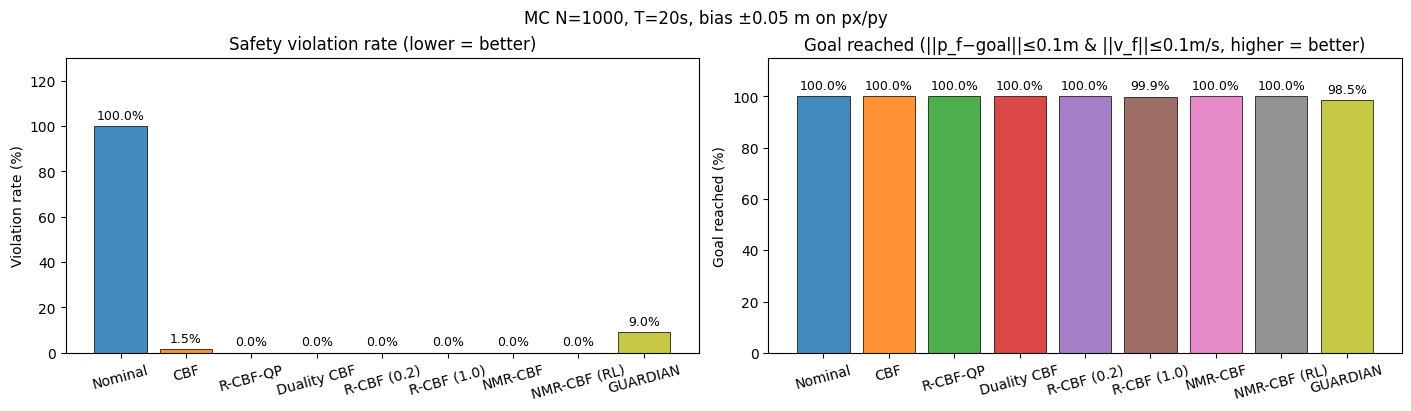

In [20]:
fig3, (ax_viol, ax_goal) = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
names  = list(mc_results.keys())
colors = plt.cm.tab10(np.linspace(0, 0.8, len(names)))

# Left: safety violation rate (lower is better)
rates = [mc_results[n] * 100 for n in names]
bars  = ax_viol.bar(names, rates, color=colors, alpha=0.85, edgecolor='k', lw=0.6)
ax_viol.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=9)
ax_viol.set_ylabel('Violation rate (%)')
ax_viol.set_ylim(0, max(max(rates) * 1.3, 10))
ax_viol.set_title('Safety violation rate (lower = better)')
ax_viol.tick_params(axis='x', rotation=15)

# Right: goal reached rate (higher is better)
goals = [mc_goals[n] * 100 for n in names]
bars2 = ax_goal.bar(names, goals, color=colors, alpha=0.85, edgecolor='k', lw=0.6)
ax_goal.bar_label(bars2, fmt='{:.1f}%', padding=3, fontsize=9)
ax_goal.set_ylabel('Goal reached (%)')
ax_goal.set_ylim(0, 115)
ax_goal.set_title(f'Goal reached (||p_f−goal||≤{GOAL_TOL}m & ||v_f||≤{VEL_TOL}m/s, higher = better)')
ax_goal.tick_params(axis='x', rotation=15)

fig3.suptitle(f'MC N={N_MC}, T={T*DT:.0f}s, bias ±{float(STATE_EPS[0]):.2f} m on px/py')
plt.show()

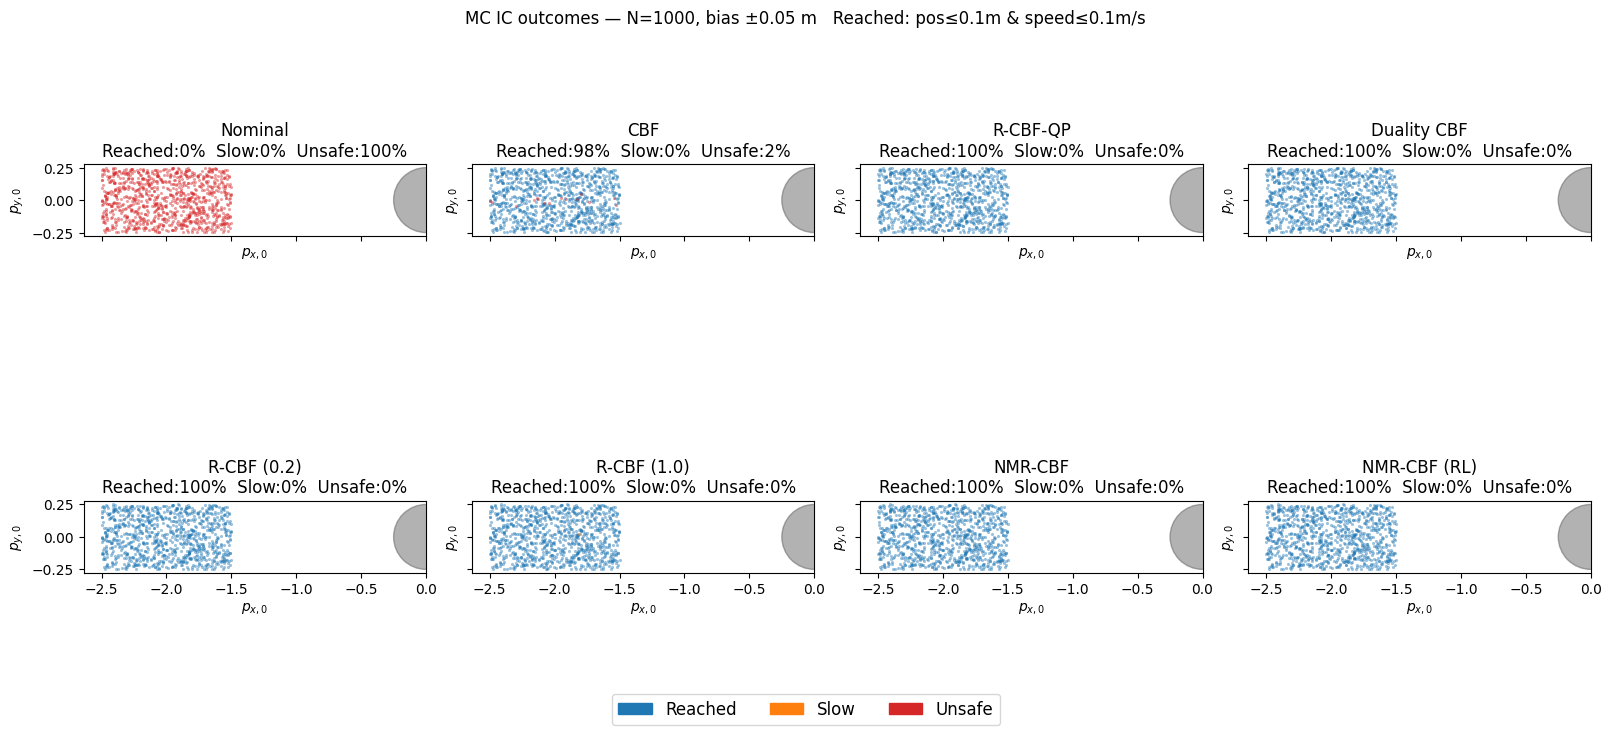

In [21]:
import matplotlib.patches as mpatches

# Three outcome categories — concise labels
_CAT_INFO = [
    ('Reached', 'C0', lambda v, r: (~v) &   r),   # safe AND goal reached
    ('Slow',   'C1', lambda v, r: (~v) & (~r)),  # safe but goal not reached
    ('Unsafe',  'C3', lambda v, r:   v        ),  # obstacle violated
]

_px0 = np.array(x0s[:, 0])
_py0 = np.array(x0s[:, 2])

fig_ic, axes_ic = plt.subplots(2, 4, figsize=(16, 7), layout='constrained',
                                sharex=True, sharey=True)
axes_ic = axes_ic.flatten()

for ax, (name, _fn) in zip(axes_ic, mc_viols.items()):
    viol    = mc_viols[name]
    reached = mc_reached[name]
    for cat, col, mask_fn in _CAT_INFO:
        mask = mask_fn(viol, reached)
        ax.scatter(_px0[mask], _py0[mask], c=col, s=5, alpha=0.45,
                   linewidths=0, zorder=3)
    ax.add_patch(Circle((0, 0), R_OBS,
                        facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=4))
    # ax.scatter(*GOAL_MC[:2], s=60, color='k', marker='+', linewidths=1.5, zorder=5)
    ax.set_aspect('equal')
    ax.set_xlim(None, 0.0)
    ax.set_xlabel(r'$p_{x,0}$'); ax.set_ylabel(r'$p_{y,0}$')
    n_r = int(((~viol) &   reached).sum())
    n_s = int(((~viol) & (~reached)).sum())
    n_u = int(viol.sum())
    ax.set_title(f'{name}\nReached:{n_r/N_MC:.0%}  Slow:{n_s/N_MC:.0%}  Unsafe:{n_u/N_MC:.0%}')

# Shared legend
_handles = [mpatches.Patch(color=col, label=cat) for cat, col, _ in _CAT_INFO]
fig_ic.legend(handles=_handles, loc='lower center', ncol=3, fontsize=12,
              bbox_to_anchor=(0.5, -0.04))
fig_ic.suptitle(
    f'MC IC outcomes — N={N_MC}, bias ±{float(STATE_EPS[0]):.2f} m   '
    f'Reached: pos≤{GOAL_TOL}m & speed≤{VEL_TOL}m/s')
plt.show()

## Outcome-rate table across epsilon values

Loads all cached MC results from `_mc_results_dir` (one file per `STATE_EPS` value) and prints
a LaTeX table with **Reach / Slow / Unsafe** rates (%) for each policy.

To populate more columns: change `STATE_EPS`, re-run the MC cell and save cell, then re-run this cell.

In [22]:
# ── Table: reach / slow / unsafe rates across epsilon values ─────────────────
import pickle
from pathlib import Path

result_files = sorted((_mc_results_dir).glob('mc_eps_*.pkl'))

if not result_files:
    print("No saved MC results found. Run the MC + save cells for each STATE_EPS value first.")
else:
    _all_cached = []
    for fp in result_files:
        with open(fp, 'rb') as fh:
            _all_cached.append(pickle.load(fh))
    _all_cached.sort(key=lambda r: float(r['STATE_EPS'][0]))

    def _eps_filter_dbint(results, subset):
        if subset is None:
            return results
        return [r for r in results if any(abs(r['STATE_EPS'][0] - e) < 1e-4 for e in subset)]

    # ── Select which epsilon values appear in the table (None = all available) ─
    TABLE_EPS_SUBSET = [0.1, 0.2, 0.4, 0.6]# None   # e.g. [0.1, 0.2, 0.4, 0.6]

    table_results = _eps_filter_dbint(_all_cached, TABLE_EPS_SUBSET)
    if not table_results:
        print(f"No results match TABLE_EPS_SUBSET={TABLE_EPS_SUBSET}")
    else:
        approaches     = list(table_results[0]['violation_rates'].keys())
        table_eps_vals = [float(r['STATE_EPS'][0]) for r in table_results]

        TABLE_DISPLAY_NAMES = {
            'Nominal':       'Nominal',
            'CBF':           'CBF',
            'R-CBF-QP':      'R-CBF-QP',
            'Duality CBF':   'Duality CBF',
            'R-CBF (0.2)':   r'R-CBF ($\gamma{=}0.2$)',
            'R-CBF (1.0)':   r'R-CBF ($\gamma{=}1.0$)',
            'NMR-CBF':       'NMR-CBF',
            'NMR-CBF (RL)':  'NMR-CBF (RL)',
            'GUARDIAN':      'GUARDIAN',
        }

        TABLE_CATEGORIES = [
            ('Non-robust',                           ['Nominal', 'CBF']),
            (r'\shortstack[l]{Set-based\\robust}',   ['Duality CBF', 'GUARDIAN']),
            (r'\shortstack[l]{Point-based\\robust}', None),   # None = auto-fill
        ]
        _explicit = {a for _, lst in TABLE_CATEGORIES if lst for a in lst}
        _extra    = [a for a in approaches if a not in _explicit
                     and a not in {'NMR-CBF', 'NMR-CBF (RL)', 'R-CBF-QP'}]
        TABLE_CATEGORIES[-1] = (TABLE_CATEGORIES[-1][0],
                                ['R-CBF-QP'] + _extra + ['NMR-CBF', 'NMR-CBF (RL)'])

        # ── Build LaTeX ───────────────────────────────────────────────────────
        n_eps    = len(table_eps_vals)
        col_spec = 'll' + 'ccc' * n_eps
        lines    = [
            r'\begin{table}[t]', r'\centering',
            (r'\caption{Outcome rates (\%) vs.\ position noise $\varepsilon_p$ (m) --- '
             r'Reach$\,/\,$Slow$\,/\,$Unsafe}'),
            r'\label{tab:mc_outcome_rates_dbint}',
            f'\\begin{{tabular}}{{{col_spec}}}', r'\toprule',
        ]
        # Grouped eps header
        header1 = r'Category & Approach'
        for eps in table_eps_vals:
            header1 += f' & \\multicolumn{{3}}{{c}}{{$\\varepsilon_p={eps:.2f}$}}'
        lines.append(header1 + r' \\')
        # Per-eps cmidrule (columns 3,4,5 for first eps; 6,7,8 for second; etc.)
        cmidrule_parts = []
        for k in range(n_eps):
            c0 = 3 + k * 3
            cmidrule_parts.append(f'\\cmidrule(lr){{{c0}--{c0+2}}}')
        lines.append(' '.join(cmidrule_parts))
        # Sub-header: Reach / Slow / Unsafe repeated per eps
        header2 = r' & '
        for _ in table_eps_vals:
            header2 += r' & Reach & Slow & Unsafe'
        lines.append(header2 + r' \\')
        # Data rows
        for cat_name, cat_approaches in TABLE_CATEGORIES:
            cat_rows = [a for a in cat_approaches if a in approaches]
            if not cat_rows:
                continue
            lines.append(r'\midrule')
            for i, approach in enumerate(cat_rows):
                disp = TABLE_DISPLAY_NAMES.get(approach, approach)
                row  = (f'\\multirow{{{len(cat_rows)}}}{{*}}{{{cat_name}}} & {disp}'
                        if i == 0 else f' & {disp}')
                for res in table_results:
                    unsafe  = float(res['violation_rates'].get(approach, float('nan')))
                    reached = float(res['goal_rates'].get(approach, float('nan')))
                    slow    = 1.0 - unsafe - reached
                    row    += f' & {100*reached:.1f} & {100*slow:.1f} & {100*unsafe:.1f}'
                lines.append(row + r' \\')
        lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
        print('\n'.join(lines))
        print(f'\n({n_eps} ε values, {len(approaches)} approaches, N={table_results[0]["N_MC"]})')

\begin{table}[t]
\centering
\caption{Outcome rates (\%) vs.\ position noise $\varepsilon_p$ (m) --- Reach$\,/\,$Slow$\,/\,$Unsafe}
\label{tab:mc_outcome_rates_dbint}
\begin{tabular}{llccccccccc}
\toprule
Category & Approach & \multicolumn{3}{c}{$\varepsilon_p=0.10$} & \multicolumn{3}{c}{$\varepsilon_p=0.20$} & \multicolumn{3}{c}{$\varepsilon_p=0.40$} \\
\cmidrule(lr){3--5} \cmidrule(lr){6--8} \cmidrule(lr){9--11}
 &  & Reach & Slow & Unsafe & Reach & Slow & Unsafe & Reach & Slow & Unsafe \\
\midrule
\multirow{2}{*}{Non-robust} & Nominal & 100.0 & -100.0 & 100.0 & 100.0 & -100.0 & 100.0 & 100.0 & -91.3 & 91.3 \\
 & CBF & 100.0 & -5.7 & 5.7 & 100.0 & -19.5 & 19.5 & 100.0 & -44.9 & 44.9 \\
\midrule
\multirow{2}{*}{\shortstack[l]{Set-based\\robust}} & Duality CBF & 100.0 & 0.0 & 0.0 & 99.5 & 0.5 & 0.0 & 97.3 & 2.7 & 0.0 \\
 & GUARDIAN & 92.6 & -0.8 & 8.2 & 16.7 & 65.8 & 17.5 & 2.1 & 92.2 & 5.7 \\
\midrule
\multirow{5}{*}{\shortstack[l]{Point-based\\robust}} & R-CBF-QP & 100.0 & 0.0 & 0.0 &

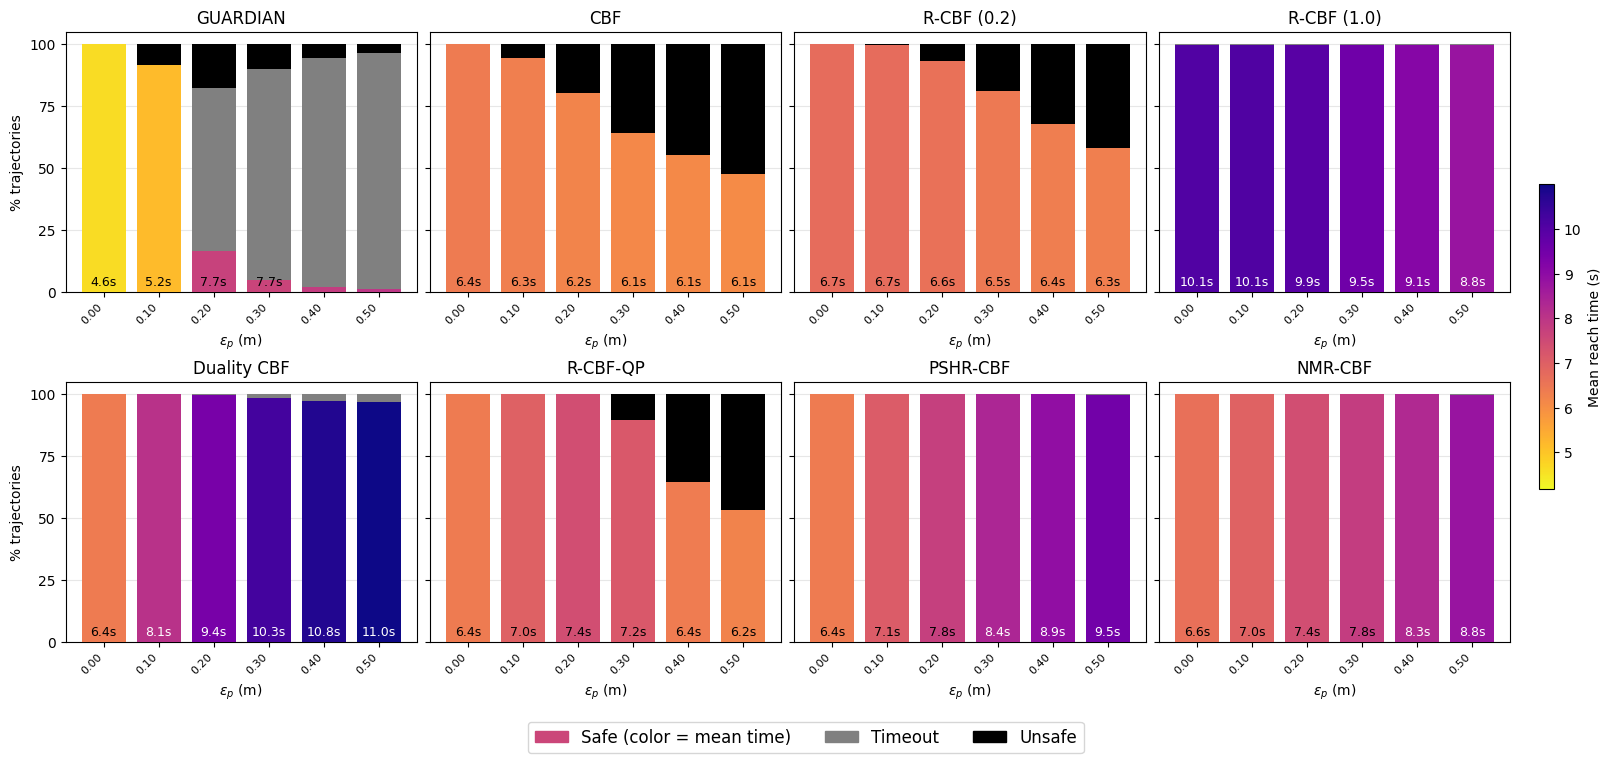

In [27]:
# ── Stacked bar chart: reach / slow / unsafe vs epsilon, one subplot per approach ──
import pickle
from pathlib import Path

result_files = sorted(_mc_results_dir.glob('mc_eps_*.pkl'))

if not result_files:
    print("No saved MC results found.")
else:
    _all_cached = []
    for fp in result_files:
        with open(fp, 'rb') as fh:
            _all_cached.append(pickle.load(fh))
    _all_cached.sort(key=lambda r: float(r['STATE_EPS'][0]))

    # ── Select which epsilon values appear in the plot (None = all available) ──
    PLOT_EPS_SUBSET = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]   # e.g. [0.1, 0.2, 0.4, 0.6]
    if PLOT_EPS_SUBSET is not None:
        _all_cached = [r for r in _all_cached
                       if any(abs(float(r['STATE_EPS'][0]) - e) < 1e-4 for e in PLOT_EPS_SUBSET)]

    eps_vals = [float(r['STATE_EPS'][0]) for r in _all_cached]
    x        = np.arange(len(eps_vals))

    # ── Policy display order (reorder / omit entries as desired) ─────────────
    PLOT_ORDER = [
        'GUARDIAN',
        'CBF',
        'R-CBF (0.2)',
        'R-CBF (1.0)',
        'Duality CBF',
        'R-CBF-QP',
        'PSHR-CBF',
        'NMR-CBF (RL)',
        'NMR-CBF',
        'Nominal',
    ]
    # PLOT_ORDER = [
    #     'PSHR-CBF',
    #     'NMR-CBF',
    #     'NMR-CBF (RL)',
    #     'Nominal',
    #     'Duality CBF',
    # ]
    _available = set(_all_cached[0]['violation_rates'].keys())
    approaches = [a for a in PLOT_ORDER if a in _available]
    x_labels   = [f'{e:.2f}' for e in eps_vals]

    # ── Mean reach-time coloring ──────────────────────────────────────────────
    # When True, the Reached bar is coloured by mean reach time (safe ICs only);
    # a shared colorbar replaces the solid blue.  When False, solid REACH_COLOR.
    SHOW_REACH_TIME_COLOR = True
    SHOW_MEAN_TIME_LABEL  = True   # print mean reach time on the Reached bar
    MEAN_TIME_WHITE_THRESH = 8.0   # use white text above this value (seconds)

    SLOW_COLOR   = 'grey'
    UNSAFE_COLOR = 'k'
    REACH_COLOR  = 'C0'   # used only when SHOW_REACH_TIME_COLOR = False

    _rt_cmap = plt.cm.plasma_r

    def _mean_reach_time(r, approach):
        """Mean reach time over safe-reached ICs only. Non-finishing ICs excluded."""
        rt_arr      = np.array(r.get('reach_time_array', {}).get(approach, []))
        viol_arr    = np.array(r['violation_array'].get(approach, []), dtype=bool)
        reached_arr = np.array(r['reached_array'].get(approach,  []), dtype=bool)
        safe        = reached_arr & (~viol_arr)  # goal reached and never violated
        return float(np.nanmean(rt_arr[safe])) if (safe.any() and rt_arr.size) else float('nan')

    if SHOW_REACH_TIME_COLOR:
        # Compute all mean times up front so colorbar bounds reflect actual data
        _all_mean_times = {
            a: [_mean_reach_time(r, a) for r in _all_cached] for a in approaches}
        _nom_means = _all_mean_times.get('Nominal', list(_all_mean_times.values())[0])
        _rt_tmin   = float(np.nanmin(_nom_means)) if not all(np.isnan(v) for v in _nom_means) else 0.0
        _all_finite = [v for vals in _all_mean_times.values() for v in vals if not np.isnan(v)]
        _rt_tmax   = float(max(_all_finite)) if _all_finite else T * DT
        _rt_norm   = plt.Normalize(vmin=_rt_tmin, vmax=_rt_tmax)

    fig, axes = plt.subplots(2, 4, figsize=(16, 7), layout='constrained',
                             sharey=True)
    axes = axes.flatten()

    for ax, approach in zip(axes, approaches):
        reached_pct = np.array([
            100 * float(r['goal_rates'].get(approach, 0.0)) for r in _all_cached])
        unsafe_pct  = np.array([
            100 * float(r['violation_rates'].get(approach, 0.0)) for r in _all_cached])
        slow_pct    = 100.0 - reached_pct - unsafe_pct

        if SHOW_REACH_TIME_COLOR:
            for i in range(len(eps_vals)):
                mt    = _all_mean_times[approach][i]
                color = _rt_cmap(_rt_norm(mt)) if not np.isnan(mt) else '0.85'
                ax.bar(i, reached_pct[i], color=color, zorder=3)
        else:
            ax.bar(x, reached_pct, color=REACH_COLOR, zorder=3)

        ax.bar(x, slow_pct,   color=SLOW_COLOR,   bottom=reached_pct,              zorder=3)
        ax.bar(x, unsafe_pct, color=UNSAFE_COLOR, bottom=reached_pct + slow_pct,   zorder=3)

        # Mean reach-time label overlaid at the base of each Reached bar
        if SHOW_MEAN_TIME_LABEL and approach != 'Nominal':
            for i in range(len(eps_vals)):
                mt = _all_mean_times[approach][i]
                if np.isnan(mt) or reached_pct[i] < 3:
                    continue
                txt_color = 'white' if mt > MEAN_TIME_WHITE_THRESH else 'black'
                ax.text(i, 1.5, f'{mt:.1f}s', ha='center', va='bottom',
                        fontsize=9, color=txt_color, zorder=5)

        if approach != 'NMR-CBF (RL)' and approach != 'NMR-CBF':
            ax.set_title(approach)
        elif approach == 'NMR-CBF (RL)':
            ax.set_title('NMR-CBF')
        else:
            ax.set_title('NMR-CBF (pretrain)')
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
        ax.set_xlabel(r'$\varepsilon_p$ (m)')
        ax.set_ylim(0, 105)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.grid(axis='y', alpha=0.3, zorder=0)

    for ax in axes[len(approaches):]:
        ax.set_visible(False)

    axes[0].set_ylabel('% trajectories')
    if len(approaches) > 4:
        axes[4].set_ylabel('% trajectories')

    if SHOW_REACH_TIME_COLOR:
        sm = plt.cm.ScalarMappable(cmap=_rt_cmap, norm=_rt_norm)
        sm.set_array([])
        fig.colorbar(sm, ax=axes[:len(approaches)], label='Mean reach time (s)',
                     shrink=0.5, pad=0.02)
        _reach_patch = plt.Rectangle((0, 0), 1, 1, color=_rt_cmap(0.5),
                                     label='Safe (color = mean time)')
    else:
        _reach_patch = plt.Rectangle((0, 0), 1, 1, color=REACH_COLOR, label='Reached')

    _handles = [
        _reach_patch,
        plt.Rectangle((0, 0), 1, 1, color=SLOW_COLOR,   label='Timeout'),
        plt.Rectangle((0, 0), 1, 1, color=UNSAFE_COLOR, label='Unsafe'),
    ]
    fig.legend(_handles, [h.get_label() for h in _handles],
               loc='lower center', ncol=3, fontsize=12,
               bbox_to_anchor=(0.5, -0.08))
    # fig.suptitle(
    #     f'Outcome rates vs. position noise $\\varepsilon_p$  '
    #     f'(N={_all_cached[0]["N_MC"]:,}, pos tol={GOAL_TOL}m, vel tol={VEL_TOL}m/s)')
    plt.show()


## Reach-time scatter — how long does it take to reach the goal?

One subplot per approach. Each dot is one MC initial condition, coloured by time-to-goal (seconds). Grey dots never reached the goal (unsafe or slow).

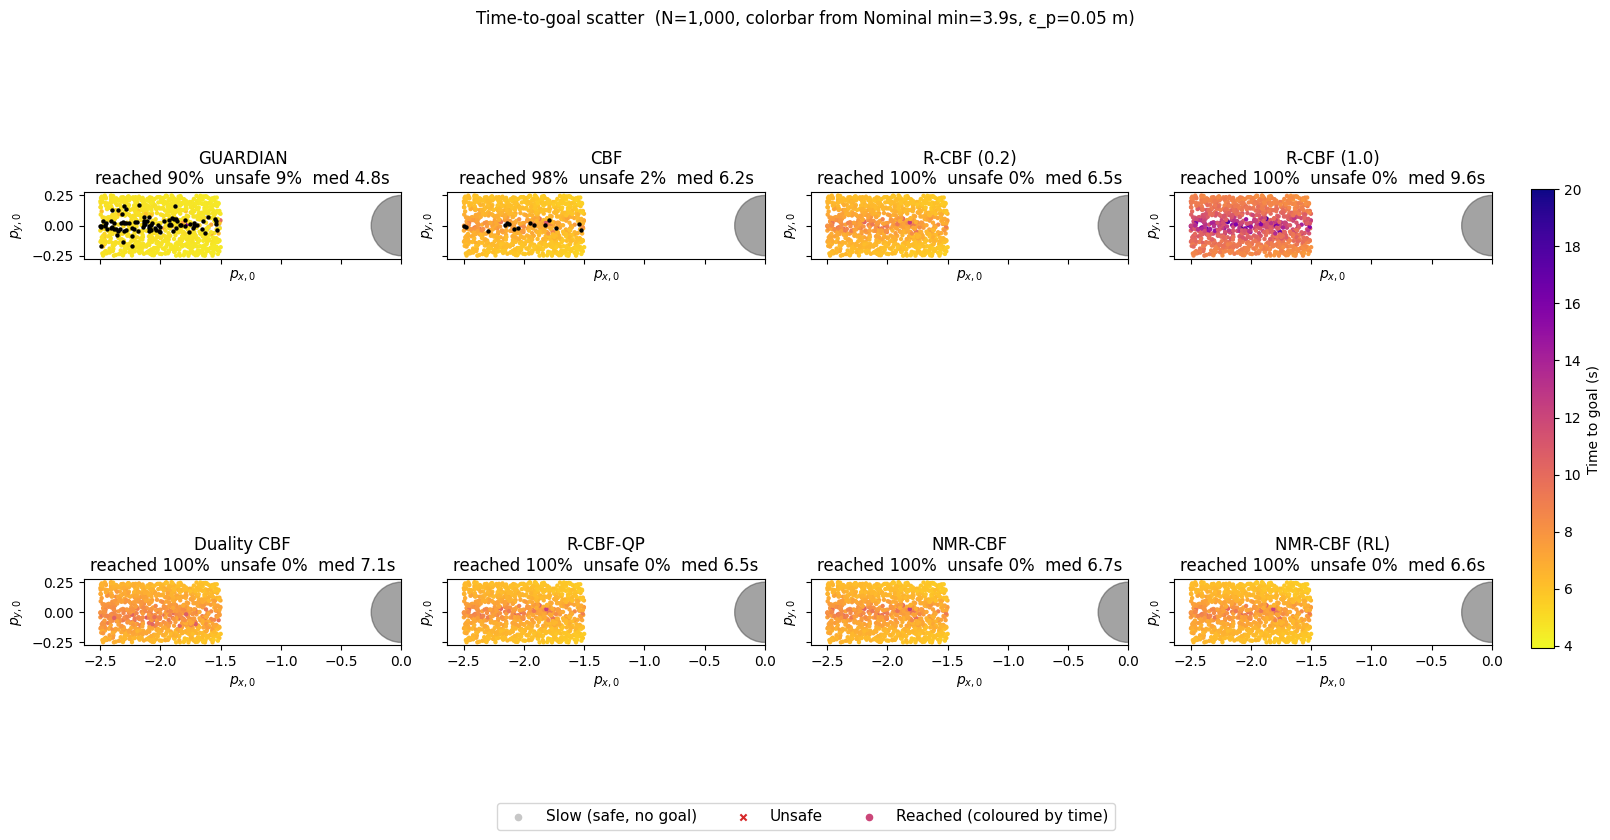

In [24]:
# ── Reach-time scatter: IC coloured by time-to-goal ──────────────────────────
_px0 = np.array(x0s[:, 0])
_py0 = np.array(x0s[:, 2])

# Policy display order — same list as the stacked bar chart above
_rt_order   = [a for a in PLOT_ORDER if a in mc_reach_times]
_t_max_plot = T * DT   # colour scale upper bound (= simulation end time)

# Colorbar minimum: smallest reach time among Nominal trajectories that got there
_nom_rt  = mc_reach_times.get('Nominal', mc_reach_times[_rt_order[0]])
_t_min_plot = float(np.nanmin(_nom_rt)) if not np.all(np.isnan(_nom_rt)) else 0.0

_cmap = plt.cm.plasma_r
_norm = plt.Normalize(vmin=_t_min_plot, vmax=_t_max_plot)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), layout='constrained',
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, approach in zip(axes, _rt_order):
    rt      = mc_reach_times[approach]   # (N,) — NaN where never reached the goal
    viol    = mc_viols[approach]         # (N,) bool — obstacle violated
    reached      = ~np.isnan(rt)
    reached_safe = reached & (~viol)     # reached goal and never violated
    slow         = (~reached) & (~viol)  # safe but never reached

    # Slow: light grey
    ax.scatter(_px0[slow], _py0[slow],
               c='0.78', s=10, linewidths=0, zorder=2)
    # Reached safely: coloured by time
    if reached_safe.any():
        ax.scatter(_px0[reached_safe], _py0[reached_safe],
                   c=rt[reached_safe], cmap=_cmap, norm=_norm,
                   s=10, linewidths=0, zorder=3)
    # Unsafe: red marker on top, no colour dot underneath
    ax.scatter(_px0[viol], _py0[viol],
               c='k', s=10, linewidths=0.0, zorder=4)

    ax.add_patch(plt.Circle((0, 0), R_OBS,
                             facecolor='0.4', edgecolor='0.35', alpha=0.6, zorder=5))
    ax.set_aspect('equal')
    ax.set_xlim(None, 0.0)
    ax.set_xlabel(r'$p_{x,0}$')
    ax.set_ylabel(r'$p_{y,0}$')
    n_r = int(reached_safe.sum())
    n_u = int(viol.sum())
    med = float(np.nanmedian(rt[reached_safe])) if n_r > 0 else float('nan')
    ax.set_title(f'{approach}\nreached {n_r/len(rt):.0%}  unsafe {n_u/len(rt):.0%}  med {med:.1f}s')

for ax in axes[len(_rt_order):]:
    ax.set_visible(False)

sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[:len(_rt_order)], label='Time to goal (s)',
             shrink=0.6, pad=0.02)

# Shared legend
_leg_handles = [
    plt.scatter([], [], c='0.78', s=20, label='Slow (safe, no goal)'),
    plt.scatter([], [], c='C3',   s=20, marker='x', label='Unsafe'),
    plt.scatter([], [], c=[_cmap(0.5)], s=20, label='Reached (coloured by time)'),
]
fig.legend(handles=_leg_handles, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Time-to-goal scatter  (N={len(_px0):,}, '
    f'colorbar from Nominal min={_t_min_plot:.1f}s, '
    f'ε_p={float(STATE_EPS[0]):.2f} m)')
plt.show()


## Per-step compute time

Warm up each policy (one JIT compile), then time `N_REPEATS` full rollouts.

  Nominal         3.1 ms ± 0.1 ms  (0.008 ms/step)
  CBF             118.5 ms ± 4.5 ms  (0.296 ms/step)
  R-CBF-QP        129.4 ms ± 6.2 ms  (0.323 ms/step)
  Duality CBF     1156.2 ms ± 15.9 ms  (2.891 ms/step)
  R-CBF (0.2)     115.5 ms ± 3.0 ms  (0.289 ms/step)
  R-CBF (1.0)     125.8 ms ± 0.5 ms  (0.315 ms/step)
  NMR-CBF         139.4 ms ± 5.7 ms  (0.348 ms/step)
  NMR-CBF (RL)    127.5 ms ± 2.2 ms  (0.319 ms/step)
  PSH-CBF         254.3 ms ± 6.7 ms  (0.636 ms/step)
  GUARDIAN        103.1 ms ± 0.7 ms  (0.258 ms/step)


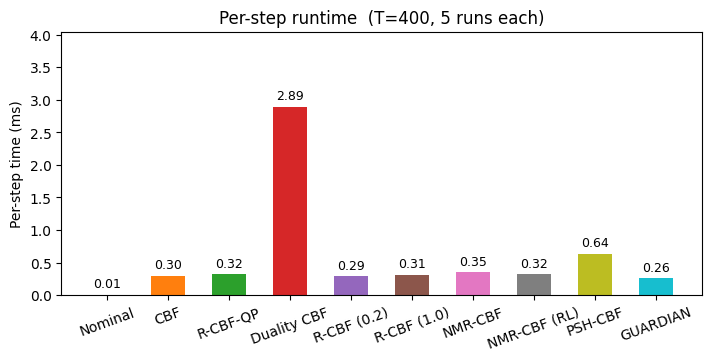

In [30]:
import time

# Warm up (JIT compile) all policies
for _name, _fn in _ALL_ROLLOUTS:
    jax.block_until_ready(_fn(X0_DEMO, BIAS_DEMO))

N_REPEATS = 5
timing = {}
for pol_name, rollout_fn in _ALL_ROLLOUTS:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(rollout_fn(X0_DEMO, BIAS_DEMO))
        times.append(time.perf_counter() - t0)
    timing[pol_name] = times
    print(f'  {pol_name:<14}  {np.mean(times)*1e3:.1f} ms ± {np.std(times)*1e3:.1f} ms'
          f'  ({np.mean(times)/T*1e3:.3f} ms/step)')

names    = list(timing.keys())
per_step = [1e3 * np.mean(v) / T for v in timing.values()]
colors   = plt.cm.tab10(np.linspace(0, 0.9, len(names)))

fig, ax = plt.subplots(figsize=(7, 3.5), layout='constrained')
bars = ax.bar(names, per_step, color=colors, width=0.55)
ax.bar_label(bars, labels=[f'{v:.2f}' for v in per_step], padding=3, fontsize=9)
ax.set(ylabel='Per-step time (ms)', ylim=(0, max(per_step) * 1.4),
       title=f'Per-step runtime  (T={T}, {N_REPEATS} runs each)')
ax.tick_params(axis='x', labelrotation=20)
plt.show()